In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import copy

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier,RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier)
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier


import scipy.stats as stats
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
def labeled_barplot(data, feature, feature_2, order, perc=False, n=None):
    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))
        
    ax = sns.countplot(
        data=data,
        x=feature,
        palette='viridis',
        order=order,
        hue=feature_2,
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=9,
            xytext=(0, 5),
            textcoords="offset points"
        )  # annotate the percentage

    plt.show()  # show the plot

In [3]:
def histogram_boxplot(data, feature, figsize=(16, 6), kde=False, bins=None, hue=None):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True,
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter",
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [4]:
def stacked_barplot(data, predictor, target):
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5), cmap='viridis')
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [5]:
def model_performance_classification_custom(model, predictors, target):
    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [6]:
def confusion_matrix_custom(model, predictors, target, label=None):
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)

    if label:
        title = f"Confusion Matrix: {label} dataset"
    else:
        title = "Confusion Matrix"

    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues")
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

In [7]:
df = pd.read_csv('EasyVisa.csv')
pd.set_option(
    "display.float_format", lambda x: "%.2f" % x
)

In [8]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified


In [9]:
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [10]:
df.shape

(25480, 12)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [12]:
df[df.duplicated()]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status


#### Observations
* There are no missing or duplicate values in the dataset.
* We should convert the object type columns to categories, which reduces the memory required to store the dataframe.

In [14]:
for col in df.columns[df.dtypes=='object']:
    df[col] = df[col].astype('category')

In [15]:
df.drop(labels='case_id', axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  category
 1   education_of_employee  25480 non-null  category
 2   has_job_experience     25480 non-null  category
 3   requires_job_training  25480 non-null  category
 4   no_of_employees        25480 non-null  int64   
 5   yr_of_estab            25480 non-null  int64   
 6   region_of_employment   25480 non-null  category
 7   prevailing_wage        25480 non-null  float64 
 8   unit_of_wage           25480 non-null  category
 9   full_time_position     25480 non-null  category
 10  case_status            25480 non-null  category
dtypes: category(8), float64(1), int64(2)
memory usage: 797.7 KB


#### Observations
* There are 9 columns of the dtype object, 1 columns of the dtype float64, and 2 columns of the dtype int64.
* The target variable for the models is case_status.
* case_id is a randomly assigned by INA for each case, which should not provide any material information for model building.
* The memory required to store the dataframe is now ~800kB, a third the size of the original dataframe.

## EDA - Exploratory Data Analysis

## Univariate Analysis

#### 1. Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification? 

In [20]:
df.groupby('education_of_employee')['case_status'].value_counts()

education_of_employee  case_status
Bachelor's             Certified      6367
                       Denied         3867
Doctorate              Certified      1912
                       Denied          280
High School            Denied         2256
                       Certified      1164
Master's               Certified      7575
                       Denied         2059
Name: count, dtype: int64

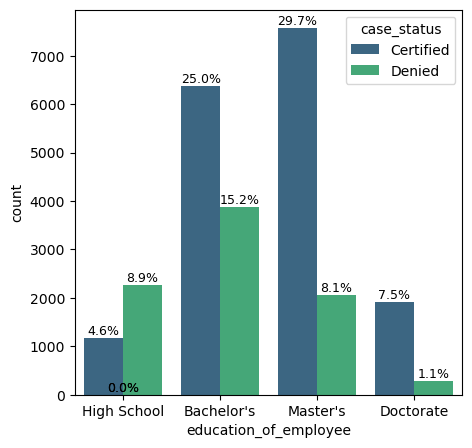

In [21]:
labeled_barplot(df,'education_of_employee','case_status', order=["High School","Bachelor's","Master's","Doctorate"], perc=True)

#### Observations
* As the graph aboves shows, the ratio of applications being certified versus denied increases considerably as an applicant's highest level of education achieved increases.
* The ratio of an applicant with a high school diploma being approved versus denied is ~1:2, whereas the same ratio for an applicant with a doctorate is ~7:1.

#### 2. How does the visa status vary across different continents? 

In [24]:
df.groupby('continent')['case_status'].value_counts()

continent      case_status
Africa         Certified        397
               Denied           154
Asia           Certified      11012
               Denied          5849
Europe         Certified       2957
               Denied           775
North America  Certified       2037
               Denied          1255
Oceania        Certified        122
               Denied            70
South America  Certified        493
               Denied           359
Name: count, dtype: int64

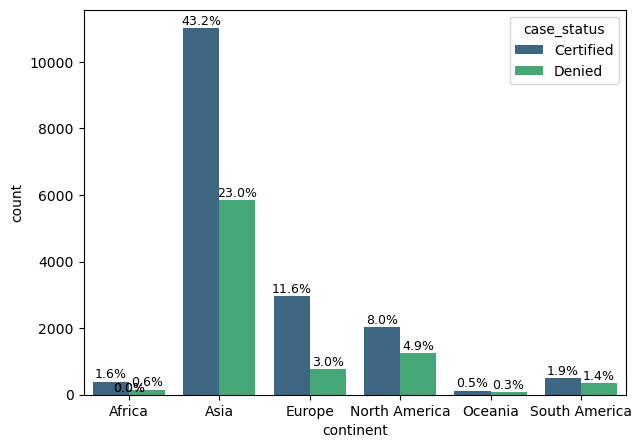

In [25]:
labeled_barplot(df,'continent','case_status', order=None, perc=True)

#### Observations
* Applicants from Asia comprise ~2/3 of all applications and these applicants have almost a 2:1 ratio of approvals to denials.
* An application from a European applicant has the best ratio of approvals to denials (~4:1).

#### 3. Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status? 

In [28]:
df.groupby('has_job_experience')['case_status'].value_counts()

has_job_experience  case_status
N                   Certified       5994
                    Denied          4684
Y                   Certified      11024
                    Denied          3778
Name: count, dtype: int64

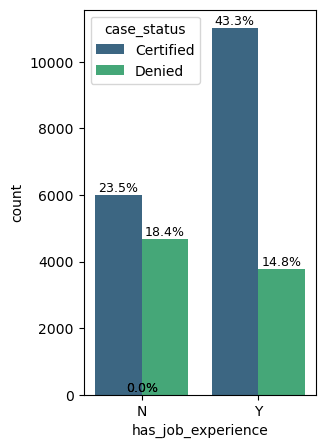

In [29]:
labeled_barplot(df,'has_job_experience','case_status', order=None, perc=True)

#### Observations
* Applicants with job experience have a ratio of approved to denied applications of ~3:1, whereas the same ratio for applicants without job experience have around a 5:4 ratio (i.e., approximately equivalent).

#### 4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa? 

In [32]:
df.groupby('unit_of_wage')['case_status'].value_counts()

unit_of_wage  case_status
Hour          Denied          1410
              Certified        747
Month         Certified         55
              Denied            34
Week          Certified        169
              Denied           103
Year          Certified      16047
              Denied          6915
Name: count, dtype: int64

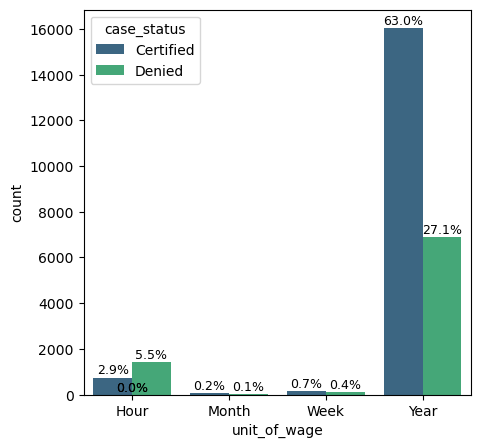

In [33]:
labeled_barplot(df,'unit_of_wage','case_status', order=None, perc=True)

#### Observations
* Applicants who are applying to work in a job with an hourly rate have a ratio of approved versus denied applications of ~1:2. Additionally, these applicants comprise only ~8% of all applications, but comprise ~17% of all denials.
* Applicants from any other unit_of_wage category have a ratio of ~2:1, with applications for jobs with annual salaries showing nearly a 2.5:1 ratio of approvals to denials.

## Data Preprocessing
- Feature engineering 
- Outlier detection and treatment

In [36]:
#show the number of rows with a value of no_of_employees less than 0, which is not a possible value
df[df.no_of_employees<0].shape

(33, 11)

In [37]:
#drop the rows with errors shown above and check the remaining number of rows
df = df[df.no_of_employees>0]
df.shape

(25447, 11)

In [38]:
#create bins to categorize companies by the size of their overall workforce
bins = [0,1000,2000,3000,4000,np.Inf]
names = ['0-1000','1000-2000','2000-3000','3000-4000','4000+']
#assign each applicant to a category which indicates the size of the company he or she is applying to
df['company_size'] = pd.cut(df['no_of_employees'], bins, labels=names)
df.company_size.value_counts()

company_size
0-1000       6208
1000-2000    5915
2000-3000    4978
4000+        4798
3000-4000    3548
Name: count, dtype: int64

In [39]:
#create bins to categorize companies by the number of years since the company was founded
bins = [0,1966,1986,1996,2006,np.Inf]
names = ['50+','30-50','20-30','10-20','0-10']
#assign each applicant to a category which indicates how long the company has been in business (i.e., a proxy for how well-established the company is)
df['company_age'] = pd.cut(df['yr_of_estab'], bins, labels=names)
df.company_age.value_counts()

company_age
10-20    8367
50+      5106
0-10     4849
30-50    3739
20-30    3386
Name: count, dtype: int64

## EDA - Exploratory Data Analysis Continues

#### 5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

In [42]:
df.groupby('unit_of_wage')['prevailing_wage'].mean()

unit_of_wage
Hour      414.77
Month   87592.86
Week    85606.82
Year    81237.54
Name: prevailing_wage, dtype: float64

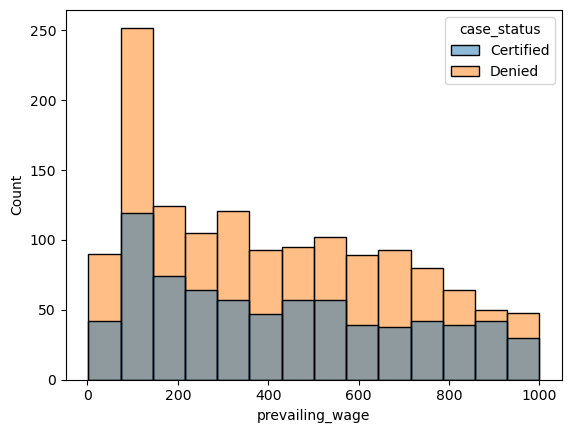

In [43]:
df_hourly = df[df.unit_of_wage=='Hour']
sns.histplot(data=df_hourly, x='prevailing_wage', hue='case_status')
plt.show()

In [44]:
bins = list(np.arange(0,1100,200))
df_hourly['income_per_day'] = pd.cut(df_hourly['prevailing_wage'], bins)
df_hourly.groupby('income_per_day')['case_status'].value_counts()

income_per_day  case_status
(0, 200]        Denied         446
                Certified      219
(200, 400]      Denied         300
                Certified      166
(400, 600]      Denied         274
                Certified      144
(600, 800]      Denied         238
                Certified      116
(800, 1000]     Denied         148
                Certified      102
Name: count, dtype: int64

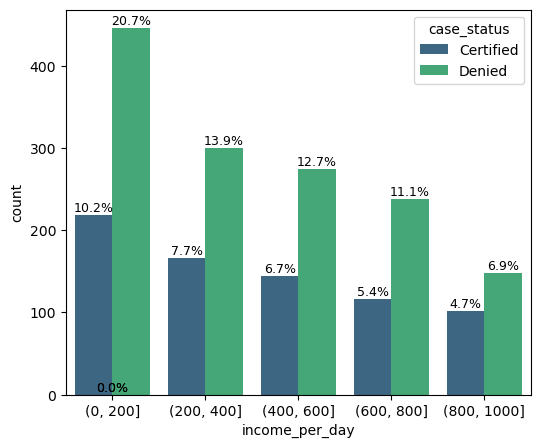

In [45]:
labeled_barplot(df_hourly,'income_per_day','case_status',perc=True,order=None)

#### Observations
- As the graphs above show, even within applicants for jobs with an 'Hour' prevailing_wage, the ratio of approved to denied applications increases considerably as prevailing_wage increases.
- Even at the highest income_per_day category, an application is still more likely to be denied than approved.

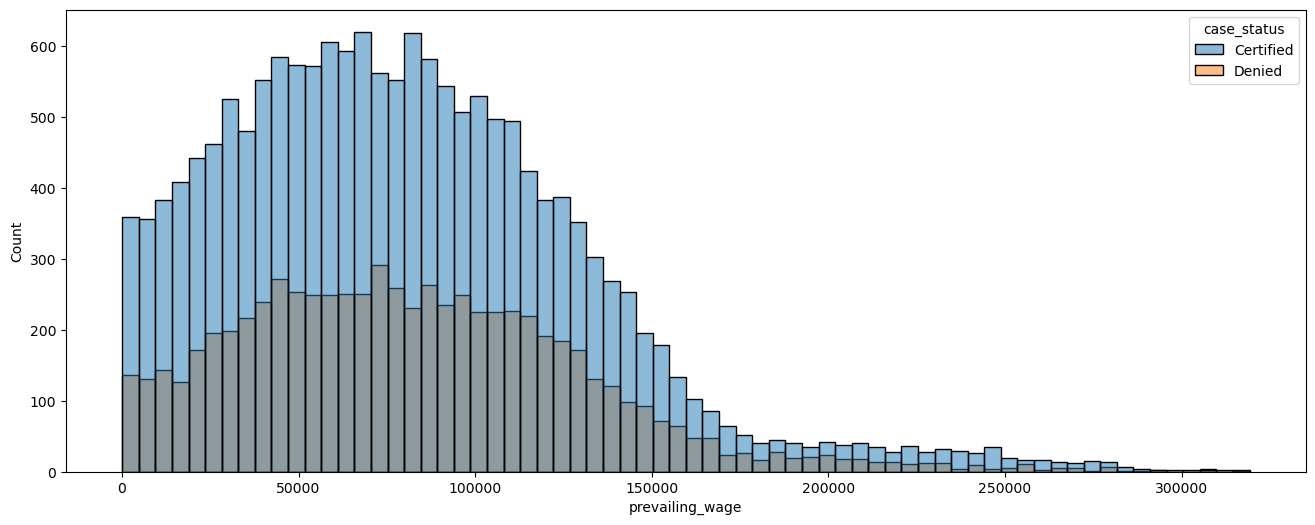

In [47]:
df_annual = df[df.unit_of_wage != "Hour"]

plt.figure(figsize=(16,6))
sns.histplot(data=df_annual, x='prevailing_wage', hue='case_status')
plt.show()

#### Observations
- The distribution of wages is (as expected) right skewed, indicating a long-tail of jobs with annual salaries above 150,000 dollars.
- As the distribution above shows, the ratio of approved to denied applications remains approximately equivalent across the range of wages.

In [49]:
bins = [0,25000,50000,75000,100000,125000,np.inf]
names = ['$0-25k','$25k-50k','$50k-75k','$75k-100k','$100k-125k','$125k+']
df_annual['income_per_year'] = pd.cut(df_annual['prevailing_wage'], bins, labels=names)
df_annual.groupby('income_per_year')['case_status'].value_counts()

income_per_year  case_status
$0-25k           Certified      2089
                 Denied          759
$25k-50k         Certified      2835
                 Denied         1232
$50k-75k         Certified      3132
                 Denied         1371
$75k-100k        Certified      3011
                 Denied         1315
$100k-125k       Certified      2405
                 Denied         1138
$125k+           Certified      2782
                 Denied         1225
Name: count, dtype: int64

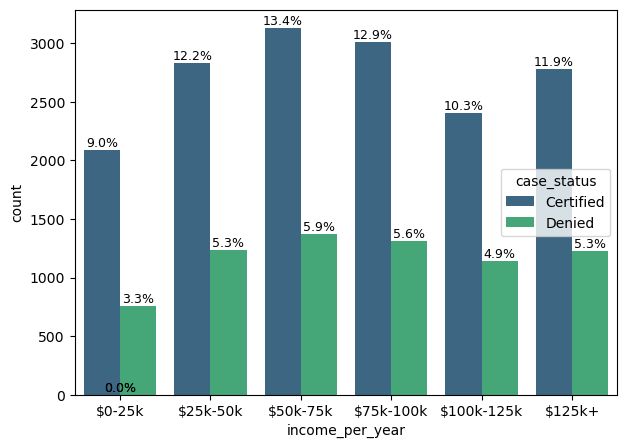

In [50]:
labeled_barplot(df_annual,'income_per_year','case_status',perc=True,order=None)

#### Observations
- In support of the observation above, there does not appear to be a significant change in ratio of approved to denied applications as income_per_year increases. To the contrary, the ratio may actually decrease as this prevailing_wage increases.
- For applications for jobs with an income_per_year wage, the highest concentration of applications is for jobs with 50,000 to 75,000 dollars per year in salary.

### Summary of Integer columns

In [53]:
df.describe(include = ['int64']).T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25447.00,5674.42,22891.84,12.00,1025.00,2112.00,3506.50,602069.00
yr_of_estab,25447.00,1979.39,42.39,1800.00,1976.00,1997.00,2005.00,2016.00


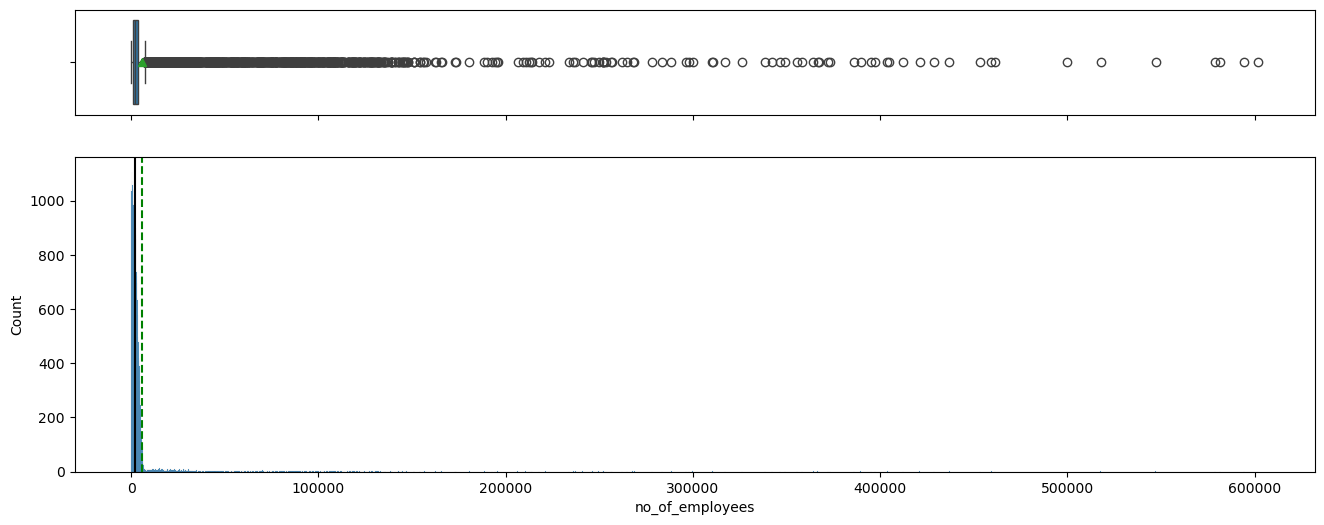

In [54]:
histogram_boxplot(df, 'no_of_employees')

#### Observations
- The data and graphs above, indicate the distribution of companies by number of employee is heavily right skewed, but without any outlier values that require further investigation or treatment.

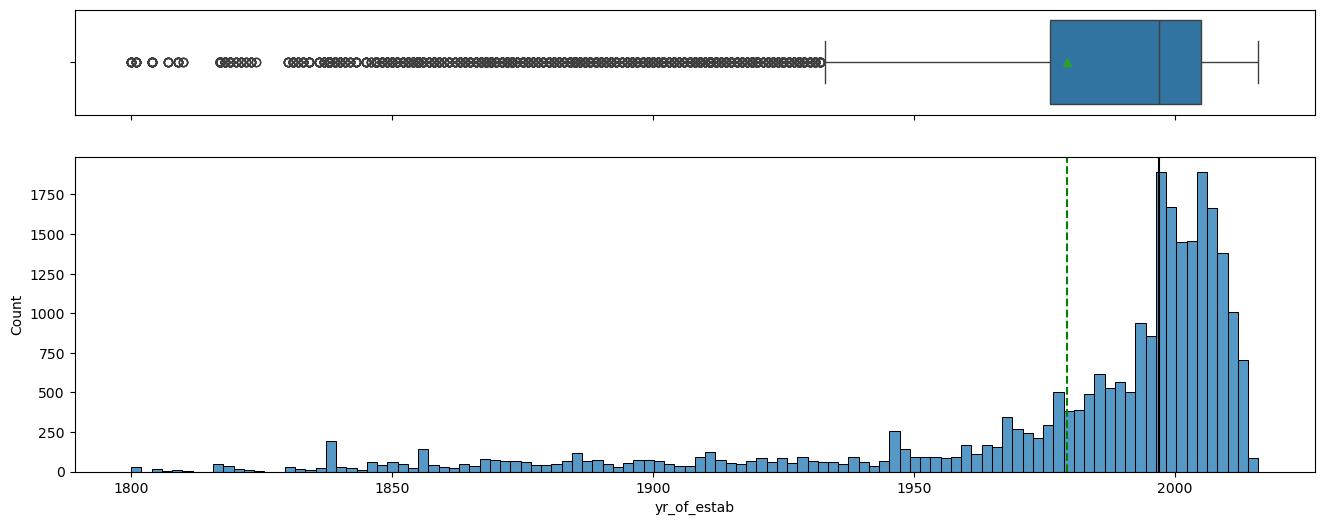

In [56]:
histogram_boxplot(df, 'yr_of_estab')

#### Observations
- The data and graphs above, indicate the distribution of companies by year of establishment (i.e., founding) is heavily left skewed, but without any outlier values which require further investigation or treatment.

### Summary of float64 variables

In [59]:
df_annual.describe(include = ['float64']).T

,count,mean,std,min,25%,50%,75%,max
prevailing_wage,23294.00,81312.84,49943.37,100.00,43860.93,76257.68,111414.45,319210.27


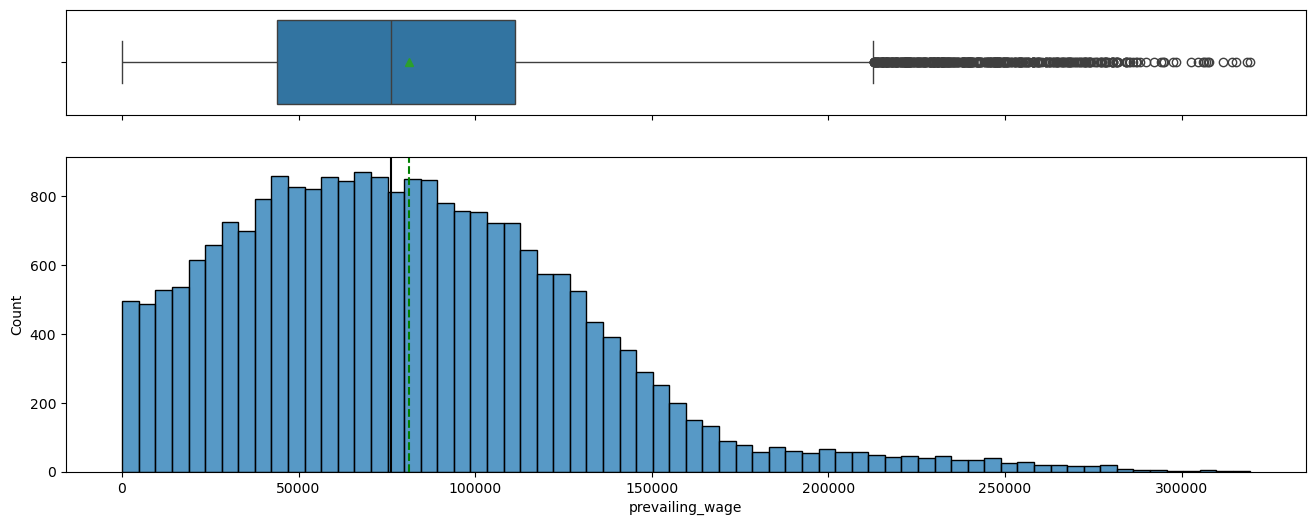

In [60]:
histogram_boxplot(df_annual,'prevailing_wage')

In [61]:
df_hourly.describe(include = ['float64']).T

,count,mean,std,min,25%,50%,75%,max
prevailing_wage,2153.00,414.77,275.05,2.14,152.70,373.20,637.31,999.92


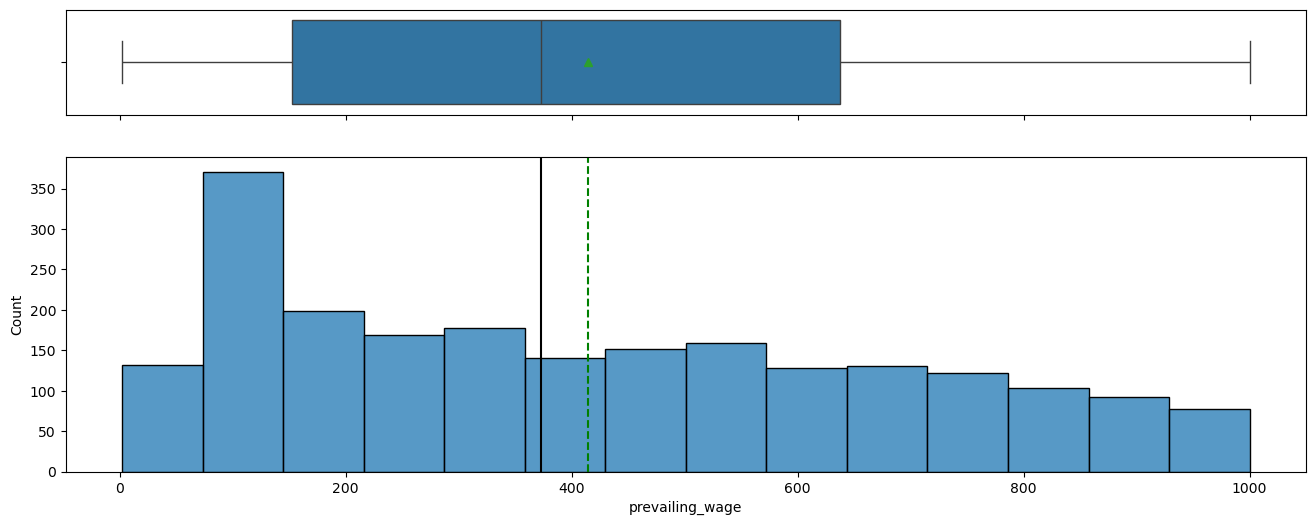

In [62]:
histogram_boxplot(df_hourly,'prevailing_wage')

## Bivariate Analysis

continent    Africa   Asia  Europe  North America  Oceania  South America  \
case_status                                                                 
All             550  16840    3727           3287      192            851   
Certified       396  11001    2953           2037      122            492   
Denied          154   5839     774           1250       70            359   

continent      All  
case_status         
All          25447  
Certified    17001  
Denied        8446  
------------------------------------------------------------------------------------------------------------------------


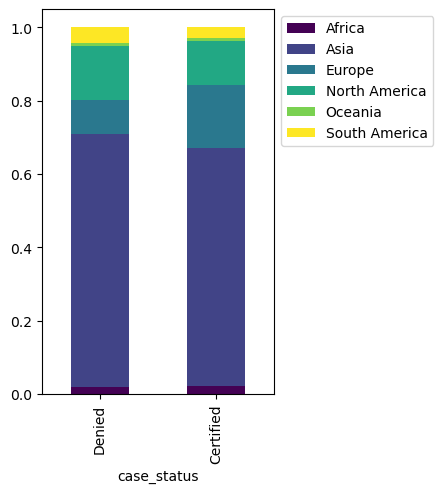

education_of_employee  Bachelor's  Doctorate  High School  Master's    All
case_status                                                               
All                         10220       2189         3416      9622  25447
Certified                    6362       1910         1164      7565  17001
Denied                       3858        279         2252      2057   8446
------------------------------------------------------------------------------------------------------------------------


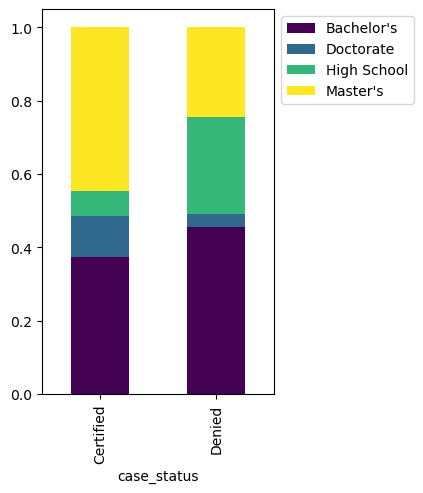

has_job_experience      N      Y    All
case_status                            
All                 10661  14786  25447
Certified            5986  11015  17001
Denied               4675   3771   8446
------------------------------------------------------------------------------------------------------------------------


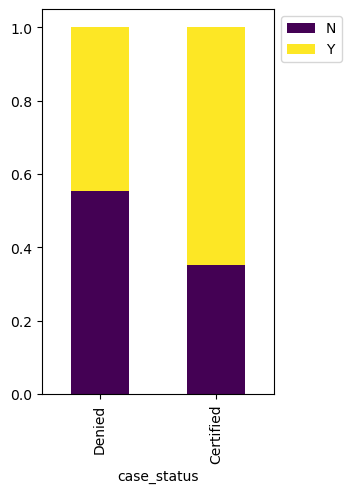

requires_job_training      N     Y    All
case_status                              
All                    22498  2949  25447
Certified              15000  2001  17001
Denied                  7498   948   8446
------------------------------------------------------------------------------------------------------------------------


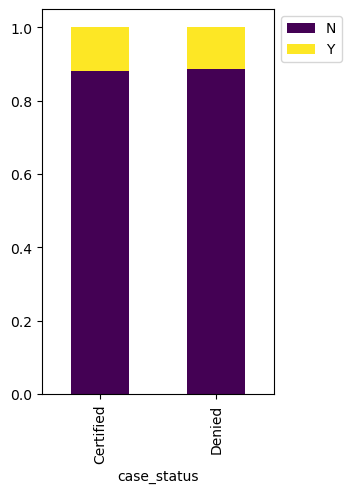

region_of_employment  Island  Midwest  Northeast  South  West    All
case_status                                                         
All                      375     4299       7189   7006  6578  25447
Certified                226     3246       4524   4908  4097  17001
Denied                   149     1053       2665   2098  2481   8446
------------------------------------------------------------------------------------------------------------------------


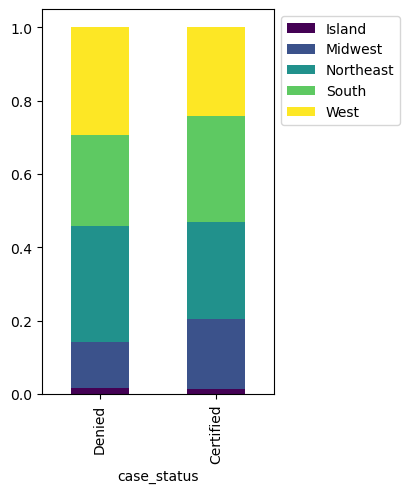

unit_of_wage  Hour  Month  Week   Year    All
case_status                                  
All           2153     89   272  22933  25447
Certified      747     55   169  16030  17001
Denied        1406     34   103   6903   8446
------------------------------------------------------------------------------------------------------------------------


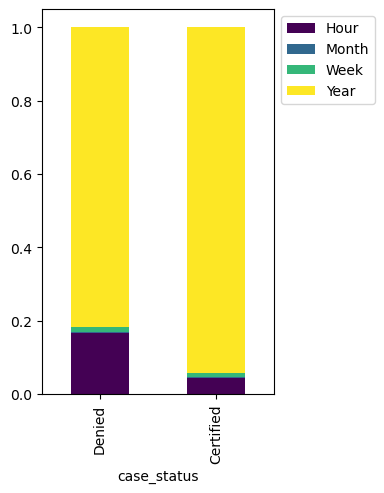

full_time_position     N      Y    All
case_status                           
All                 2706  22741  25447
Certified           1855  15146  17001
Denied               851   7595   8446
------------------------------------------------------------------------------------------------------------------------


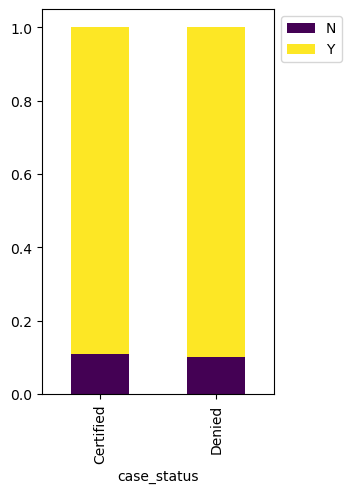

case_status  Certified  Denied    All
case_status                          
Denied               0    8446   8446
All              17001    8446  25447
Certified        17001       0  17001
------------------------------------------------------------------------------------------------------------------------


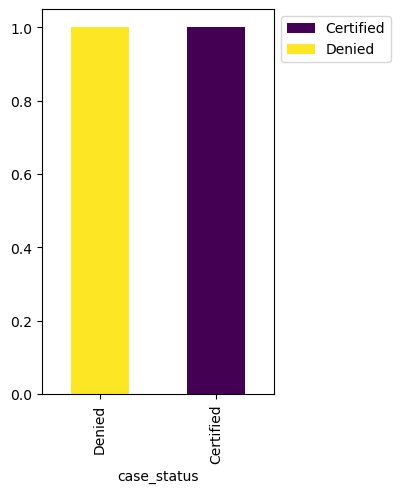

company_size  0-1000  1000-2000  2000-3000  3000-4000  4000+    All
case_status                                                        
All             6208       5915       4978       3548   4798  25447
Certified       4091       3878       3330       2341   3361  17001
Denied          2117       2037       1648       1207   1437   8446
------------------------------------------------------------------------------------------------------------------------


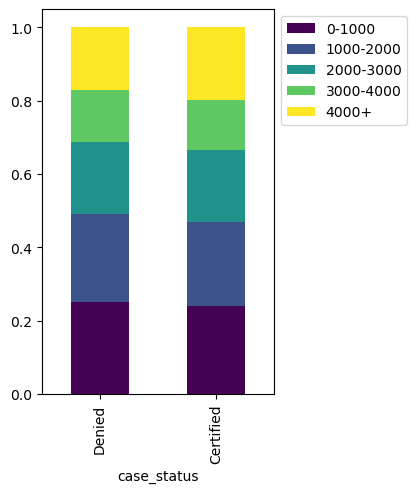

company_age   50+  30-50  20-30  10-20  0-10    All
case_status                                        
All          5106   3739   3386   8367  4849  25447
Certified    3385   2466   2226   5567  3357  17001
Denied       1721   1273   1160   2800  1492   8446
------------------------------------------------------------------------------------------------------------------------


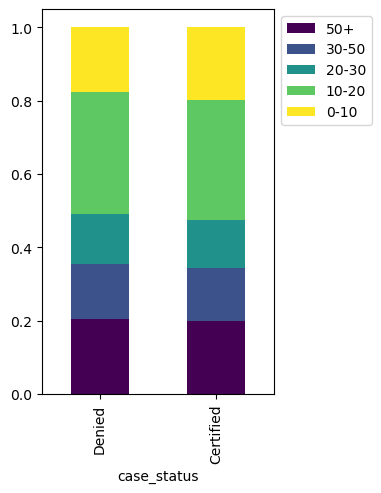

In [64]:
cols_cat = df.select_dtypes(['category'])
for i in cols_cat.columns:
    stacked_barplot(df, "case_status", i)

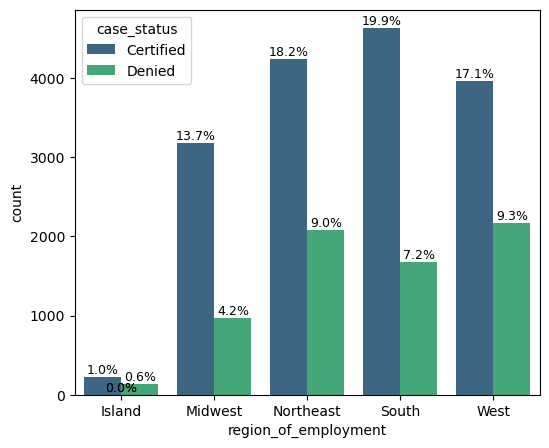

In [65]:
labeled_barplot(df_annual,'region_of_employment','case_status',perc=True,order=None)

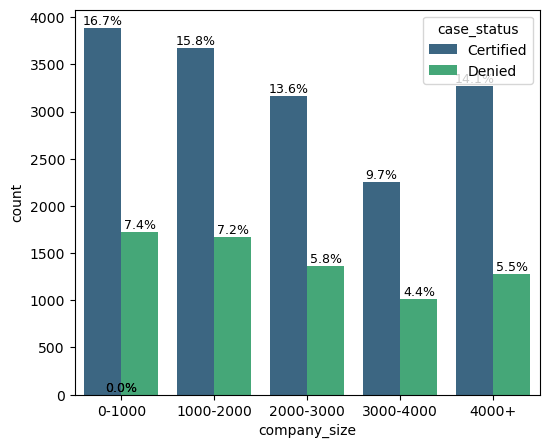

In [66]:
labeled_barplot(df_annual,'company_size','case_status',perc=True,order=None)

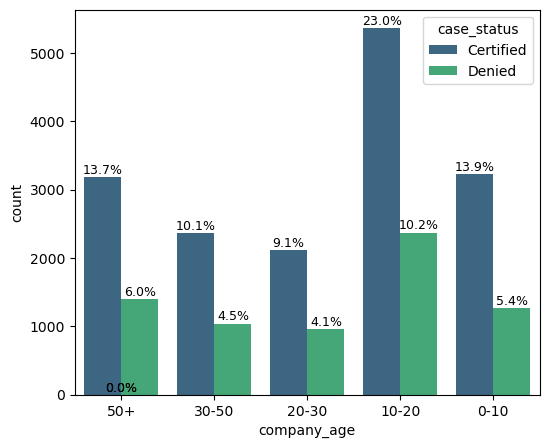

In [67]:
labeled_barplot(df_annual,'company_age','case_status',perc=True,order=None)

In [68]:
for col in df_annual.dtypes[df_annual.dtypes == 'category'].index:
    print(df_annual.groupby(col)['prevailing_wage'].mean())
    print(" ")

continent
Africa          82817.44
Asia            86237.72
Europe          62148.78
North America   80015.78
Oceania         83806.39
South America   73641.62
Name: prevailing_wage, dtype: float64
 
education_of_employee
Bachelor's    81153.74
Doctorate     67498.27
High School   80905.55
Master's      84849.96
Name: prevailing_wage, dtype: float64
 
has_job_experience
N   86478.62
Y   77881.05
Name: prevailing_wage, dtype: float64
 
requires_job_training
N   80867.28
Y   84473.58
Name: prevailing_wage, dtype: float64
 
region_of_employment
Island      96323.02
Midwest     94900.09
Northeast   77091.74
South       82174.41
West        74720.82
Name: prevailing_wage, dtype: float64
 
unit_of_wage
Hour         NaN
Month   87592.86
Week    85606.82
Year    81237.54
Name: prevailing_wage, dtype: float64
 
full_time_position
N   105484.60
Y    78161.02
Name: prevailing_wage, dtype: float64
 
case_status
Certified   80816.02
Denied      82459.91
Name: prevailing_wage, dtype: float64
 
compa

In [69]:
for col in df_hourly.dtypes[df_hourly.dtypes == 'category'].index:
    print(df_hourly.groupby(col)['prevailing_wage'].mean())
    print(" ")

continent
Africa          399.13
Asia            421.97
Europe          398.23
North America   406.39
Oceania         477.20
South America   392.17
Name: prevailing_wage, dtype: float64
 
education_of_employee
Bachelor's    413.02
Doctorate     414.55
High School   418.06
Master's      415.42
Name: prevailing_wage, dtype: float64
 
has_job_experience
N   414.31
Y   415.57
Name: prevailing_wage, dtype: float64
 
requires_job_training
N   415.88
Y   382.34
Name: prevailing_wage, dtype: float64
 
region_of_employment
Island      275.65
Midwest     427.30
Northeast   406.65
South       426.43
West        413.82
Name: prevailing_wage, dtype: float64
 
unit_of_wage
Hour    414.77
Month      NaN
Week       NaN
Year       NaN
Name: prevailing_wage, dtype: float64
 
full_time_position
N   488.47
Y   414.12
Name: prevailing_wage, dtype: float64
 
case_status
Certified   424.92
Denied      409.38
Name: prevailing_wage, dtype: float64
 
company_size
0-1000      391.91
1000-2000   433.71
2000-3000 

#### Observations
- If a job does or does not require training does not affect this ratio.
- If a job is a full-time position or not does not affect this ratio.
- If a job is located in the Midwest or South region, applicants have a higher ratio of approvals than those in the Northeast, West, and particularly the Island region.
- Jobs that applicants with doctorate degree are applying for jobs have the lowest mean prevailing wage of any education.
- Temporary (i.e., not full-time) jobs that applicants are applying for have a significantly higher prevailing wage than full-time positions.

## Data Preprocessing
- Preparing data for modeling
- Splitting the data

In [72]:
#drop the int_64 columns from the dataframe, since this information is captured through the features engineered above
df_model = df.drop(labels=['no_of_employees','yr_of_estab'], axis=1, inplace=True)

In [73]:
df["case_status"] = df["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

### Spliting the data 
We will use 70% of data for training and 30% for testing.

### Spliting the data 
We will use 70% of data for training and 30% for testing.

In [76]:
#create a dataframe of the predictor feature columns
X = df.drop('case_status',axis=1)
#create a datafrane of the predicted class (1=True, 0=False)
Y = df['case_status']

#generate dummy variables for each categorical variable
X = pd.get_dummies(X, drop_first=True)

#split the data into train and test datasets
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)

In [77]:
#create a dataframe of the predictor feature columns
X = df.drop('case_status',axis=1)
#create a datafrane of the predicted class (1=True, 0=False)
Y = df['case_status']

#generate dummy variables for each categorical variable
X = pd.get_dummies(X, drop_first=True)

#split the data into train and test datasets
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)

In [78]:
print("{0:0.2f}% data is in training set".format((len(x_train)/len(df.index)) * 100))
print("{0:0.2f}% data is in test set".format((len(x_test)/len(df.index)) * 100))

70.00% data is in training set
30.00% data is in test set


In [79]:
print("Shape of Training set : ", x_train.shape)
print("Shape of test set : ", x_test.shape)
print(' ')
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print(' ')
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17812, 27)
Shape of test set :  (7635, 27)
 
Percentage of classes in training set:
case_status
1   0.67
0   0.33
Name: proportion, dtype: float64
 
Percentage of classes in test set:
case_status
1   0.67
0   0.33
Name: proportion, dtype: float64


### Create oversampled and undersampled datasets

### Create oversampled and undersampled datasets

In [82]:
# Oversampling with SMOTE
smote = SMOTE(random_state=1)
x_train_oversampled, y_train_oversampled = smote.fit_resample(x_train, y_train)

# Undersampling with RandomUnderSampler
rus = RandomUnderSampler(random_state=1)
x_train_undersampled, y_train_undersampled = rus.fit_resample(x_train, y_train)

## Model Building

In [84]:
data_input = {
    'Original': [x_train, y_train],
    'OverSampled': [x_train_oversampled, y_train_oversampled],
    'UnderSampled': [x_train_undersampled, y_train_undersampled]
}

temp_data_stats = {}
models = ['DecisionTree', 'Bagging', 'RandomForest', 'AdaBoost', 'GradientBoosting', 'XGBoost']
counter = 0
data_stats = {}
data_stats = {key: {} for key in models}

Model running on : Original, dataset


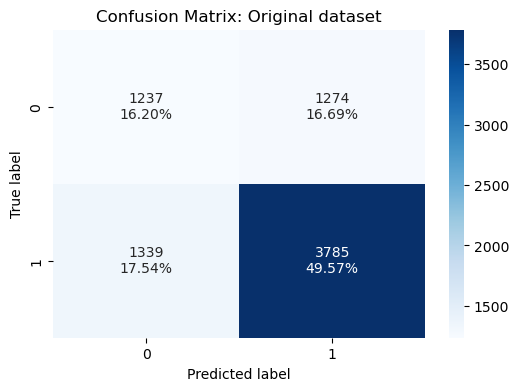

None
Training performance Original, dataset 
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00
Testing performance Original, dataset
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00



Model running on : OverSampled, dataset


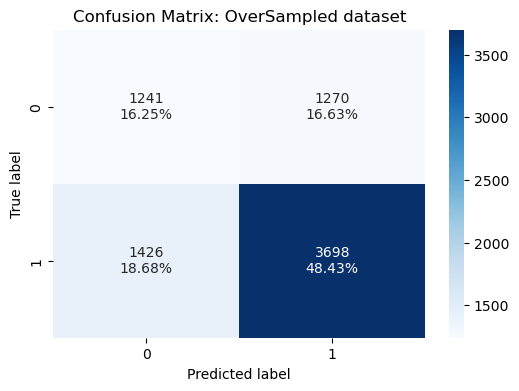

None
Training performance OverSampled, dataset 
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00
Testing performance OverSampled, dataset
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00



Model running on : UnderSampled, dataset


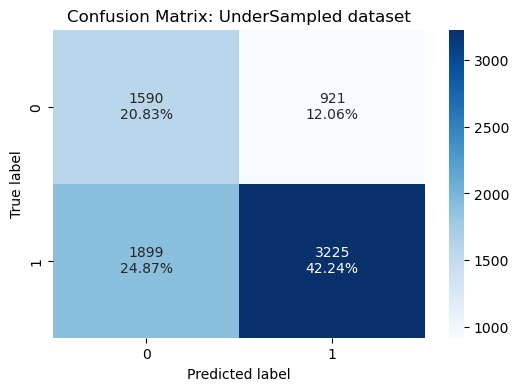

None
Training performance UnderSampled, dataset 
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00
Testing performance UnderSampled, dataset
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00





In [85]:
for key, value in data_input.items():
    dtree = DecisionTreeClassifier(criterion='gini', random_state=1, class_weight='balanced')
    dtree.fit(data_input[key][0], data_input[key][1])
    print(f"Model running on : {key}, dataset")
    
    print(confusion_matrix_custom(dtree, x_test, y_test, label=key))
    
    model_train_perf=model_performance_classification_custom(dtree, data_input[key][0], data_input[key][1])
    print(f"Training performance {key}, dataset \n",model_train_perf)
    
    model_test_perf=model_performance_classification_custom(dtree, data_input[key][0], data_input[key][1])
    print(f"Testing performance {key}, dataset\n",model_test_perf)
    print("\n\n")

    data_stats['DecisionTree'][key] = [model_train_perf, model_test_perf]

### Bagging Classifier

Model running on : Original, dataset


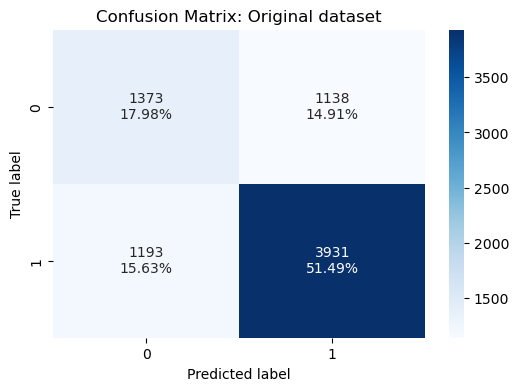

None
Training performance Original, dataset 
    Accuracy  Recall  Precision   F1
0      0.98    0.98       0.99 0.99
Testing performance Original, dataset
    Accuracy  Recall  Precision   F1
0      0.98    0.98       0.99 0.99



Model running on : OverSampled, dataset


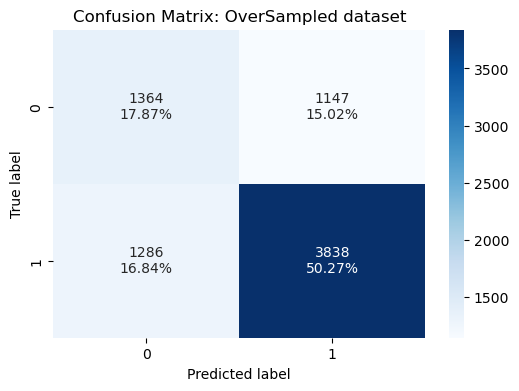

None
Training performance OverSampled, dataset 
    Accuracy  Recall  Precision   F1
0      0.99    0.98       0.99 0.99
Testing performance OverSampled, dataset
    Accuracy  Recall  Precision   F1
0      0.99    0.98       0.99 0.99



Model running on : UnderSampled, dataset


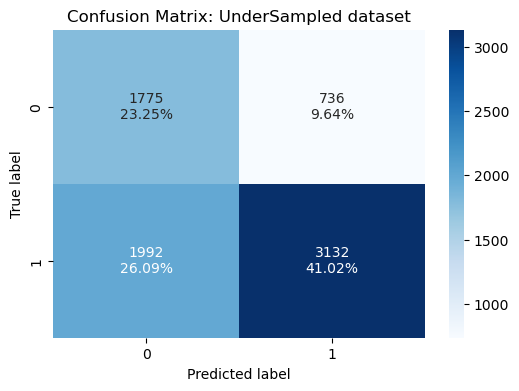

None
Training performance UnderSampled, dataset 
    Accuracy  Recall  Precision   F1
0      0.98    0.97       0.99 0.98
Testing performance UnderSampled, dataset
    Accuracy  Recall  Precision   F1
0      0.98    0.97       0.99 0.98





In [87]:
for key, value in data_input.items():
    bagging = BaggingClassifier(random_state=1)
    bagging.fit(data_input[key][0], data_input[key][1])
    print(f"Model running on : {key}, dataset")
    
    print(confusion_matrix_custom(bagging, x_test, y_test, label=key))
    
    model_train_perf=model_performance_classification_custom(bagging, data_input[key][0], data_input[key][1])
    print(f"Training performance {key}, dataset \n",model_train_perf)
    
    model_test_perf=model_performance_classification_custom(bagging, data_input[key][0], data_input[key][1])
    print(f"Testing performance {key}, dataset\n",model_test_perf)
    print("\n\n")

    data_stats['Bagging'][key] = [model_train_perf, model_test_perf]

### Random Forest

Model running on : Original, dataset


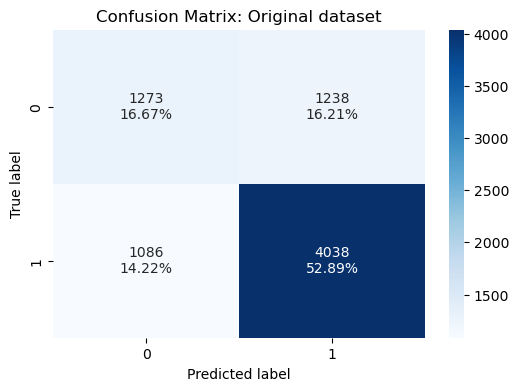

None
Training performance Original, dataset 
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00
Testing performance Original, dataset
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00



Model running on : OverSampled, dataset


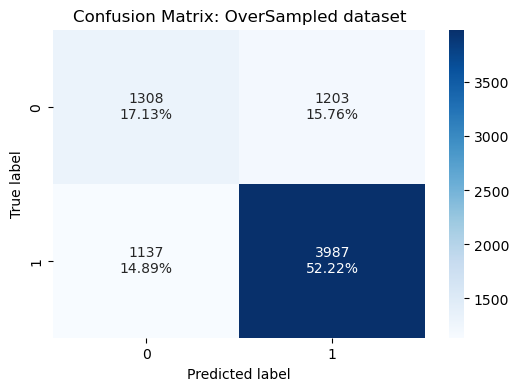

None
Training performance OverSampled, dataset 
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00
Testing performance OverSampled, dataset
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00



Model running on : UnderSampled, dataset


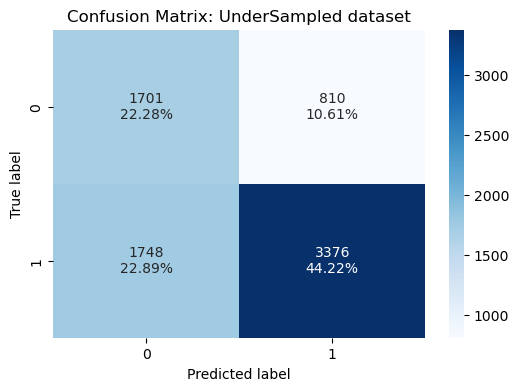

None
Training performance UnderSampled, dataset 
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00
Testing performance UnderSampled, dataset
    Accuracy  Recall  Precision   F1
0      1.00    1.00       1.00 1.00





In [89]:
for key, value in data_input.items():
    rf = RandomForestClassifier(random_state=1)
    rf.fit(data_input[key][0], data_input[key][1])
    print(f"Model running on : {key}, dataset")
    
    print(confusion_matrix_custom(rf, x_test, y_test, label=key))
    
    model_train_perf=model_performance_classification_custom(rf, data_input[key][0], data_input[key][1])
    print(f"Training performance {key}, dataset \n",model_train_perf)
    
    model_test_perf=model_performance_classification_custom(rf, data_input[key][0], data_input[key][1])
    print(f"Testing performance {key}, dataset\n",model_test_perf)
    print("\n\n")

    data_stats['RandomForest'][key] = [model_train_perf, model_test_perf]


### AdaBoost Classifier

Model running on : Original, dataset


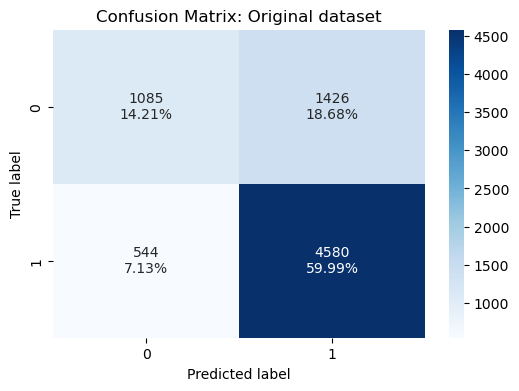

None
Training performance Original, dataset 
    Accuracy  Recall  Precision   F1
0      0.73    0.88       0.76 0.82
Testing performance Original, dataset
    Accuracy  Recall  Precision   F1
0      0.73    0.88       0.76 0.82



Model running on : OverSampled, dataset


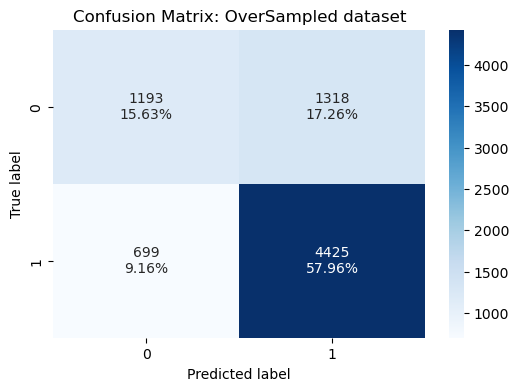

None
Training performance OverSampled, dataset 
    Accuracy  Recall  Precision   F1
0      0.78    0.85       0.75 0.80
Testing performance OverSampled, dataset
    Accuracy  Recall  Precision   F1
0      0.78    0.85       0.75 0.80



Model running on : UnderSampled, dataset


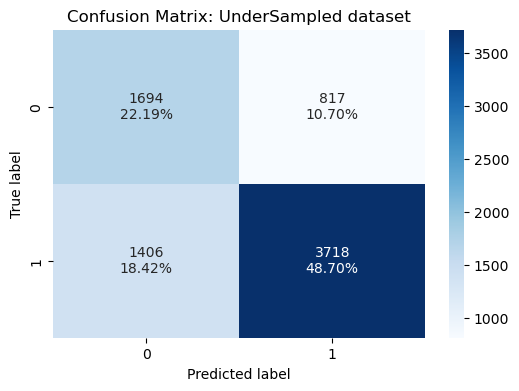

None
Training performance UnderSampled, dataset 
    Accuracy  Recall  Precision   F1
0      0.69    0.71       0.69 0.70
Testing performance UnderSampled, dataset
    Accuracy  Recall  Precision   F1
0      0.69    0.71       0.69 0.70





In [91]:
for key, value in data_input.items():
    ab_classifier=AdaBoostClassifier(random_state=1)
    ab_classifier.fit(data_input[key][0], data_input[key][1])
    print(f"Model running on : {key}, dataset")
    
    print(confusion_matrix_custom(ab_classifier, x_test, y_test, label=key))
    
    model_train_perf=model_performance_classification_custom(ab_classifier, data_input[key][0], data_input[key][1])
    print(f"Training performance {key}, dataset \n",model_train_perf)
    
    model_test_perf=model_performance_classification_custom(ab_classifier, data_input[key][0], data_input[key][1])
    print(f"Testing performance {key}, dataset\n",model_test_perf)
    print("\n\n")

    data_stats['AdaBoost'][key] = [model_train_perf, model_test_perf]

### Gradient Boosting Classifier

Model running on : Original, dataset


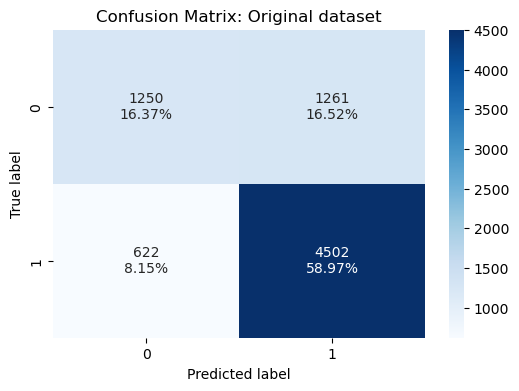

None
Training performance Original, dataset 
    Accuracy  Recall  Precision   F1
0      0.75    0.87       0.78 0.83
Testing performance Original, dataset
    Accuracy  Recall  Precision   F1
0      0.75    0.87       0.78 0.83



Model running on : OverSampled, dataset


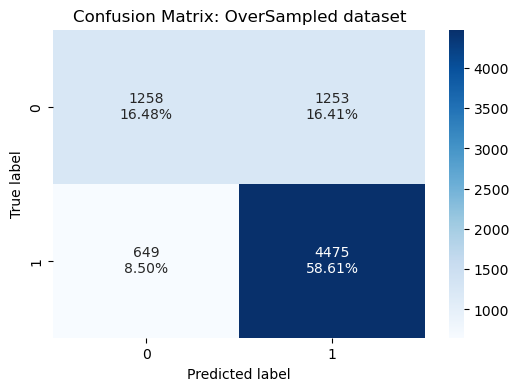

None
Training performance OverSampled, dataset 
    Accuracy  Recall  Precision   F1
0      0.80    0.86       0.76 0.81
Testing performance OverSampled, dataset
    Accuracy  Recall  Precision   F1
0      0.80    0.86       0.76 0.81



Model running on : UnderSampled, dataset


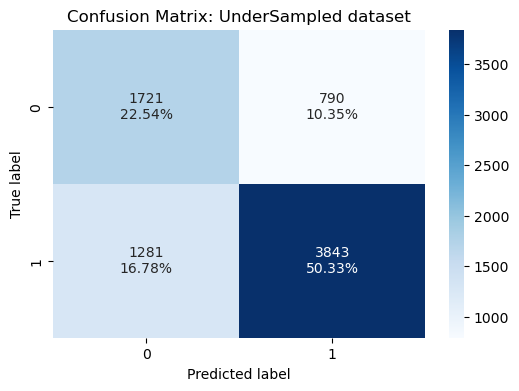

None
Training performance UnderSampled, dataset 
    Accuracy  Recall  Precision   F1
0      0.72    0.74       0.71 0.72
Testing performance UnderSampled, dataset
    Accuracy  Recall  Precision   F1
0      0.72    0.74       0.71 0.72





In [93]:
for key, value in data_input.items():
    gbc = GradientBoostingClassifier(random_state=1)
    gbc.fit(data_input[key][0], data_input[key][1])
    print(f"Model running on : {key}, dataset")
    
    print(confusion_matrix_custom(gbc, x_test, y_test, label=key))
    
    model_train_perf=model_performance_classification_custom(gbc, data_input[key][0], data_input[key][1])
    print(f"Training performance {key}, dataset \n",model_train_perf)
    
    model_test_perf=model_performance_classification_custom(gbc, data_input[key][0], data_input[key][1])
    print(f"Testing performance {key}, dataset\n",model_test_perf)
    print("\n\n")
    
    data_stats['GradientBoosting'][key] = [model_train_perf, model_test_perf]

### XGBoost Classifier

Model running on : Original, dataset


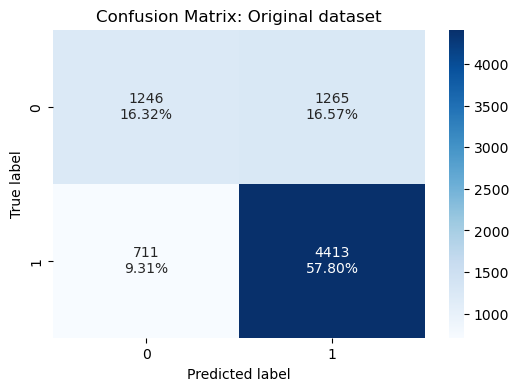

None
Training performance Original, dataset 
    Accuracy  Recall  Precision   F1
0      0.82    0.91       0.83 0.87
Testing performance Original, dataset
    Accuracy  Recall  Precision   F1
0      0.82    0.91       0.83 0.87



Model running on : OverSampled, dataset


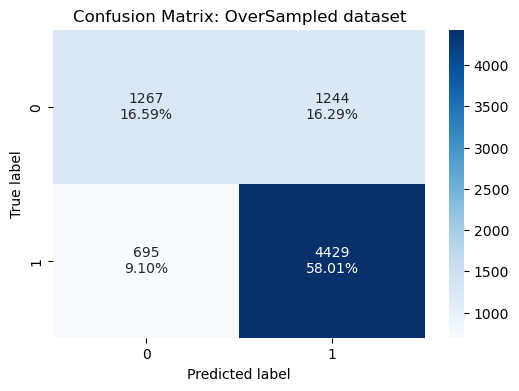

None
Training performance OverSampled, dataset 
    Accuracy  Recall  Precision   F1
0      0.84    0.90       0.81 0.85
Testing performance OverSampled, dataset
    Accuracy  Recall  Precision   F1
0      0.84    0.90       0.81 0.85



Model running on : UnderSampled, dataset


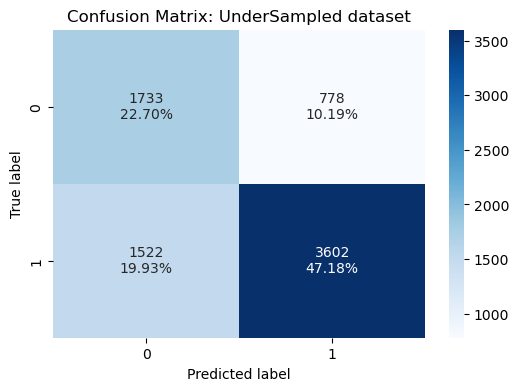

None
Training performance UnderSampled, dataset 
    Accuracy  Recall  Precision   F1
0      0.82    0.83       0.82 0.82
Testing performance UnderSampled, dataset
    Accuracy  Recall  Precision   F1
0      0.82    0.83       0.82 0.82





In [95]:
for key, value in data_input.items():
    xgb = XGBClassifier(random_state=1,eval_metric='logloss')
    xgb.fit(data_input[key][0], data_input[key][1])
    print(f"Model running on : {key}, dataset")
    
    print(confusion_matrix_custom(xgb, x_test, y_test, label=key))
    
    model_train_perf=model_performance_classification_custom(xgb, data_input[key][0], data_input[key][1])
    print(f"Training performance {key}, dataset \n",model_train_perf)
    
    model_test_perf=model_performance_classification_custom(xgb, data_input[key][0], data_input[key][1])
    print(f"Testing performance {key}, dataset\n",model_test_perf)
    print("\n\n")

    data_stats['XGBoost'][key] = [model_train_perf, model_test_perf]

In [96]:
for model_name, dataset_dict in data_stats.items():
    for dataset_type, (train_perf_df, test_perf_df) in dataset_dict.items():
        train_acc = train_perf_df['Accuracy'][0]
        test_acc = test_perf_df['Accuracy'][0]
        print(f"{model_name} | {dataset_type} | Train Accuracy: {train_acc:.2%} | Test Accuracy: {test_acc:.2%}")

        train_rc = train_perf_df['Recall'][0]
        test_rc = test_perf_df['Recall'][0]
        print(f"{model_name} | {dataset_type} | Train Recall: {train_rc:.2%} | Test Recall: {test_rc:.2%}")
        
        train_p = train_perf_df['Precision'][0]
        test_p = test_perf_df['Precision'][0]
        print(f"{model_name} | {dataset_type} | Train Precision: {train_p:.2%} | Test Precision: {test_p:.2%}")
        
        train_f1 = train_perf_df['F1'][0]
        test_f1 = test_perf_df['F1'][0]
        print(f"{model_name} | {dataset_type} | Train F1: {train_f1:.2%} | Test F1: {test_f1:.2%}")

DecisionTree | Original | Train Accuracy: 100.00% | Test Accuracy: 100.00%
DecisionTree | Original | Train Recall: 100.00% | Test Recall: 100.00%
DecisionTree | Original | Train Precision: 100.00% | Test Precision: 100.00%
DecisionTree | Original | Train F1: 100.00% | Test F1: 100.00%
DecisionTree | OverSampled | Train Accuracy: 100.00% | Test Accuracy: 100.00%
DecisionTree | OverSampled | Train Recall: 100.00% | Test Recall: 100.00%
DecisionTree | OverSampled | Train Precision: 100.00% | Test Precision: 100.00%
DecisionTree | OverSampled | Train F1: 100.00% | Test F1: 100.00%
DecisionTree | UnderSampled | Train Accuracy: 100.00% | Test Accuracy: 100.00%
DecisionTree | UnderSampled | Train Recall: 100.00% | Test Recall: 100.00%
DecisionTree | UnderSampled | Train Precision: 100.00% | Test Precision: 100.00%
DecisionTree | UnderSampled | Train F1: 100.00% | Test F1: 100.00%
Bagging | Original | Train Accuracy: 98.27% | Test Accuracy: 98.27%
Bagging | Original | Train Recall: 98.39% | Te

### Model Comparison

In [98]:
train_perf_list = []
test_perf_list = []

for model_name, dataset_dict in data_stats.items():
    for dataset_type, (train_perf_df, test_perf_df) in dataset_dict.items():
        # Name the column with both model and dataset info for clarity
        train_perf_transposed = train_perf_df.T
        train_perf_transposed.columns = [f"{model_name}_{dataset_type}"]
        train_perf_list.append(train_perf_transposed)

        # Transpose and label testing performance
        test_perf_transposed = test_perf_df.T
        test_perf_transposed.columns = [f"{model_name}_{dataset_type}"]
        test_perf_list.append(test_perf_transposed)

# Concatenate all transposed train performance DataFrames
models_train_comp_df = pd.concat(train_perf_list, axis=1)
models_test_comp_df = pd.concat(test_perf_list, axis=1)

models_train_comp_df

,DecisionTree_Original,DecisionTree_OverSampled,DecisionTree_UnderSampled,Bagging_Original,Bagging_OverSampled,Bagging_UnderSampled,RandomForest_Original,RandomForest_OverSampled,RandomForest_UnderSampled,AdaBoost_Original,AdaBoost_OverSampled,AdaBoost_UnderSampled,GradientBoosting_Original,GradientBoosting_OverSampled,GradientBoosting_UnderSampled,XGBoost_Original,XGBoost_OverSampled,XGBoost_UnderSampled
Accuracy,1.00,1.00,1.00,0.98,0.99,0.98,1.00,1.00,1.00,0.73,0.78,0.69,0.75,0.80,0.72,0.82,0.84,0.82
Recall,1.00,1.00,1.00,0.98,0.98,0.97,1.00,1.00,1.00,0.88,0.85,0.71,0.87,0.86,0.74,0.91,0.90,0.83
Precision,1.00,1.00,1.00,0.99,0.99,0.99,1.00,1.00,1.00,0.76,0.75,0.69,0.78,0.76,0.71,0.83,0.81,0.82
F1,1.00,1.00,1.00,0.99,0.99,0.98,1.00,1.00,1.00,0.82,0.80,0.70,0.83,0.81,0.72,0.87,0.85,0.82


In [99]:
models_test_comp_df

,DecisionTree_Original,DecisionTree_OverSampled,DecisionTree_UnderSampled,Bagging_Original,Bagging_OverSampled,Bagging_UnderSampled,RandomForest_Original,RandomForest_OverSampled,RandomForest_UnderSampled,AdaBoost_Original,AdaBoost_OverSampled,AdaBoost_UnderSampled,GradientBoosting_Original,GradientBoosting_OverSampled,GradientBoosting_UnderSampled,XGBoost_Original,XGBoost_OverSampled,XGBoost_UnderSampled
Accuracy,1.00,1.00,1.00,0.98,0.99,0.98,1.00,1.00,1.00,0.73,0.78,0.69,0.75,0.80,0.72,0.82,0.84,0.82
Recall,1.00,1.00,1.00,0.98,0.98,0.97,1.00,1.00,1.00,0.88,0.85,0.71,0.87,0.86,0.74,0.91,0.90,0.83
Precision,1.00,1.00,1.00,0.99,0.99,0.99,1.00,1.00,1.00,0.76,0.75,0.69,0.78,0.76,0.71,0.83,0.81,0.82
F1,1.00,1.00,1.00,0.99,0.99,0.98,1.00,1.00,1.00,0.82,0.80,0.70,0.83,0.81,0.72,0.87,0.85,0.82


#### Observations
##### High-Performing Models
- DecisionTree, RandomForest, and Bagging classifiers show perfect or near-perfect scores across all sampling methods.
- Accuracy, Recall, Precision, F1 all equal or close to 1.00.
- This suggests that these models may be overfitting the training data (especially DecisionTree).

##### Overfitting Signs
- DecisionTree shows perfect performance (1.00) across all datasets — a strong sign of overfitting, especially if test performance isn't similar.
- RandomForest and Bagging also have perfect scores in most cases — they are ensemble methods but may still overfit if not properly validated.

##### More Realistic Learning
###### AdaBoost:
- Accuracy ranges from 0.69–0.78
- Balanced tradeoff between Recall and Precision (around 0.70–0.85)
- Performs slightly better on OverSampled data

###### GradientBoosting:
- Accuracy improves from 0.72 to 0.80 with OverSampling
- F1 score aligns with Recall, indicating better balance on oversampled data

##### Insight: These models may be capturing actual signal instead of memorizing training data, hence lower but more reliable performance.

##### XGBoost – Balanced and Robust
- Accuracy ranges from 0.82 to 0.84
- Recall and F1 scores consistently high (~0.82–0.90)
- Slightly better on OverSampled dataset, suggesting it benefits from balanced class distributions

##### Conclusion: XGBoost gives consistently strong performance without overfitting — a reliable model.

##### Effect of Sampling Strategies
- Original: Strong performance in most models
- OverSampled: Boosts performance in GradientBoosting and XGBoost, especially in Recall and F1
- UnderSampled: Slight dip for some models like AdaBoost and GradientBoosting, less impact on Bagging/RandomForest
- OverSampling tends to improve Recall (detecting more positives), while UnderSampling sometimes sacrifices generalization.

#### Key Takeaways
- XGBoost and GradientBoosting balance performance and generalization well.
- DecisionTree and RandomForest may be overfitting — needs validation with test data.
- OverSampling is helpful in imbalanced classification problems, especially with boosting models.
- Training metrics alone are not sufficient — always compare with test performance to avoid overfitting traps.

## Hyperparameter Tuning

In [102]:
tuning_stats = {key: {} for key in models}

### Tuning Decision Tree

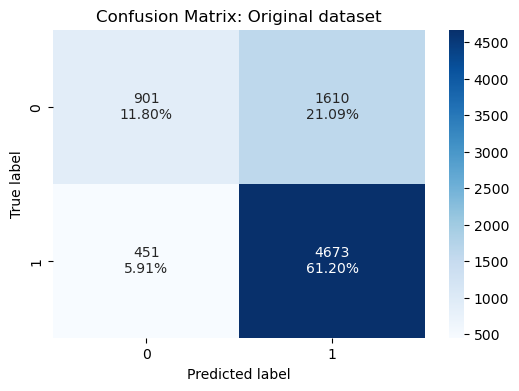

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.91       0.74 0.82
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.91       0.74 0.82


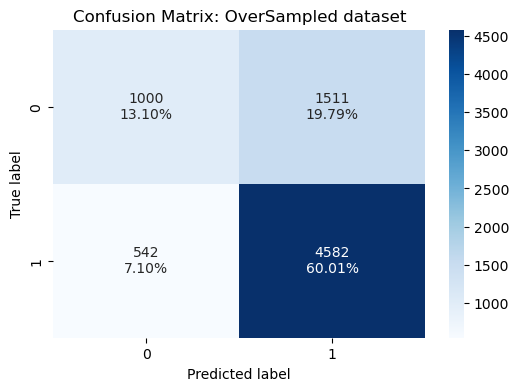

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.89       0.67 0.76
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.89       0.75 0.82


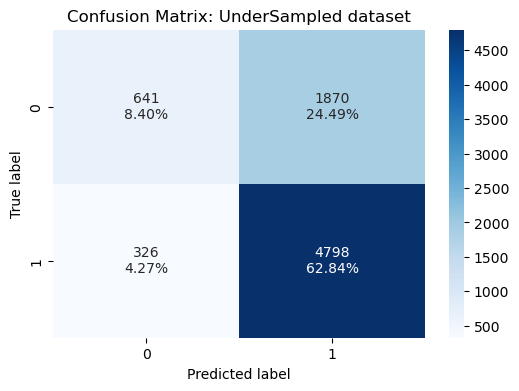

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.60    0.92       0.56 0.70
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.71    0.94       0.72 0.81


In [104]:
for key, value in data_input.items():
    dtree_estimator = DecisionTreeClassifier(random_state=1)

    # Grid of parameters to choose from
    parameters = {'max_depth': np.arange(5,30,5),
                  'min_samples_leaf': [3, 5, 7],
                  'max_leaf_nodes' : [2, 4, 6],
                  'min_impurity_decrease': [0.0001,0.001,0.01,0.1]
                 }
    
    # Type of scoring used to compare parameter combinations
    scorer = metrics.make_scorer(metrics.f1_score)
    
    # Run the grid search
    grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer, cv=5)
    grid_obj = grid_obj.fit(data_input[key][0], data_input[key][1])
    
    # Set the clf to the best combination of parameters
    dtree_estimator = grid_obj.best_estimator_
    
    # Fit the best algorithm to the data. 
    dtree_estimator.fit(data_input[key][0], data_input[key][1])

    print(confusion_matrix_custom(dtree_estimator, x_test,y_test, label=key))

    dtree_estimator_model_train_perf=model_performance_classification_custom(dtree_estimator, data_input[key][0], data_input[key][1])
    print("Training performance \n",dtree_estimator_model_train_perf)

    dtree_estimator_model_test_perf=model_performance_classification_custom(dtree_estimator, x_test, y_test)
    print("Testing performance \n",dtree_estimator_model_test_perf)

    tuning_stats['DecisionTree'][key] = [model_train_perf, model_test_perf]

### Tuning Bagging Classifier

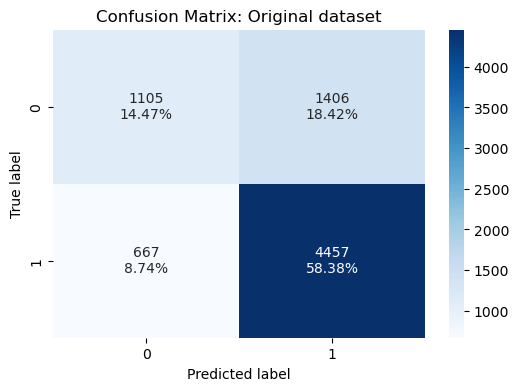

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.99    1.00       0.99 0.99
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.87       0.76 0.81


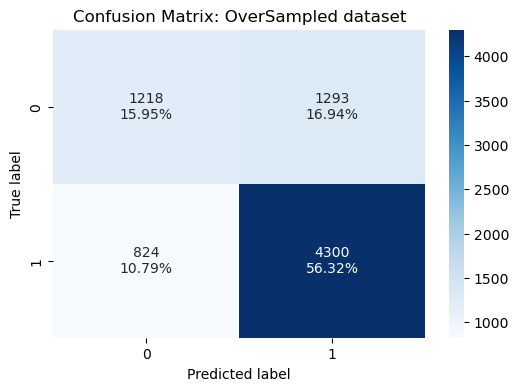

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.99    1.00       0.99 0.99
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.72    0.84       0.77 0.80


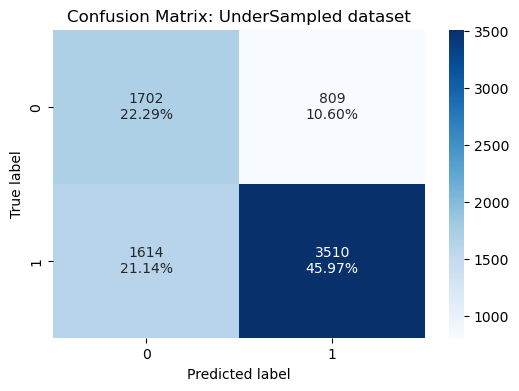

None
Training performance 
    Accuracy  Recall  Precision   F1
0      1.00    0.99       1.00 1.00
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.68    0.69       0.81 0.74


In [106]:
for key, value in data_input.items():
    # random search for bagging classifier
    parameters = {'max_samples': [0.7,0.8,0.9,1],
                  'max_features': [0.7,0.8,0.9,1],
                  'n_estimators' : np.arange(50, 100, 10)
                 }
    
    #run the randomized search
    rand_bag = RandomizedSearchCV(BaggingClassifier(random_state=1,bootstrap=True), 
                                  parameters, scoring = 'f1', cv = 5, random_state=1)
    rand_bag = rand_bag.fit(data_input[key][0], data_input[key][1])
    
    # Set the clf to the best combination of parameters
    bag_tuned = rand_bag.best_estimator_
    
    # Fit the best algorithm to the data
    bag_tuned.fit(data_input[key][0], data_input[key][1])
    
    print(confusion_matrix_custom(bag_tuned, x_test,y_test, label=key))
    
    bagging_estimator_model_train_perf=model_performance_classification_custom(bag_tuned, data_input[key][0], data_input[key][1])
    print("Training performance \n",bagging_estimator_model_train_perf)
    
    bagging_estimator_model_test_perf=model_performance_classification_custom(bag_tuned, x_test, y_test)
    print("Testing performance \n",bagging_estimator_model_test_perf)

    tuning_stats['Bagging'][key] = [model_train_perf, model_test_perf]

### Tuning Random Forest

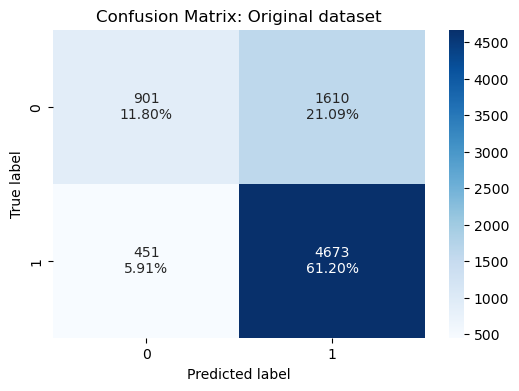

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.91       0.74 0.82
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.91       0.74 0.82


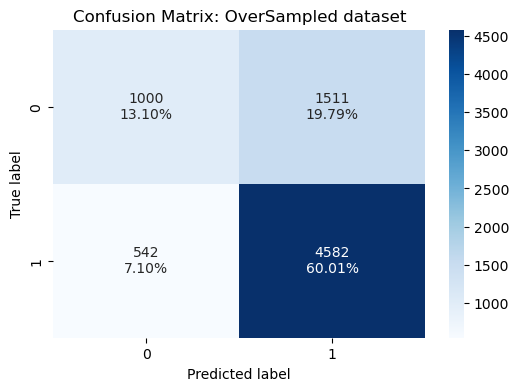

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.89       0.67 0.76
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.73    0.89       0.75 0.82


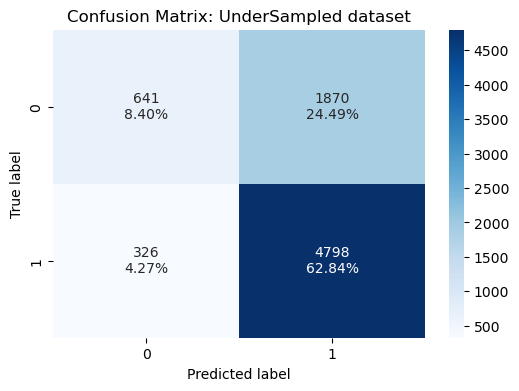

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.60    0.92       0.56 0.70
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.71    0.94       0.72 0.81


In [108]:
for key, value in data_input.items():
    rf_estimator = RandomForestClassifier(random_state=1)

    # Grid of parameters to choose from
    parameters = {"n_estimators": np.arange(10, 40, 10),
                  "min_samples_leaf": np.arange(5, 10),
                  "min_samples_split": [3, 5, 7],
                  "max_features": ["sqrt", "log2"],
                  "max_samples": np.arange(0.3, 0.7, 0.1),
    }
    
    # Run the randomized search
    rand_rf = RandomizedSearchCV(rf_estimator, parameters, scoring='f1', cv=5, n_jobs=-1, random_state=1)
    rand_rf = grid_obj.fit(data_input[key][0], data_input[key][1])
    
    # Set the clf to the best combination of parameters
    rf_estimator = rand_rf.best_estimator_
    
    # Fit the best algorithm to the data. 
    rf_estimator.fit(data_input[key][0], data_input[key][1])

    print(confusion_matrix_custom(rf_estimator, x_test,y_test, label=key))

    rf_estimator_model_train_perf=model_performance_classification_custom(rf_estimator, data_input[key][0], data_input[key][1])
    print("Training performance \n",rf_estimator_model_train_perf)

    rf_estimator_model_test_perf=model_performance_classification_custom(rf_estimator, x_test, y_test)
    print("Testing performance \n",rf_estimator_model_test_perf)

    tuning_stats['RandomForest'][key] = [model_train_perf, model_test_perf]

### Tuning AdaBoost Classifier

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/ana

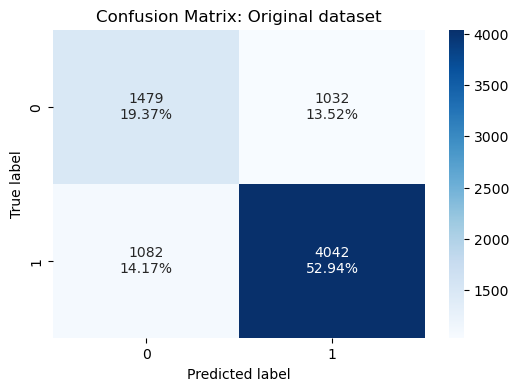

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.72    0.78       0.79 0.79
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.72    0.79       0.80 0.79


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/ana

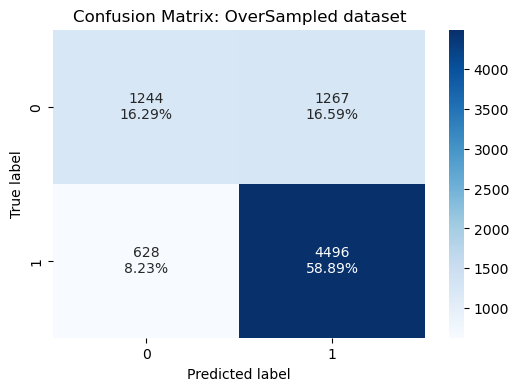

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.81    0.87       0.77 0.82
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.75    0.88       0.78 0.83


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/ana

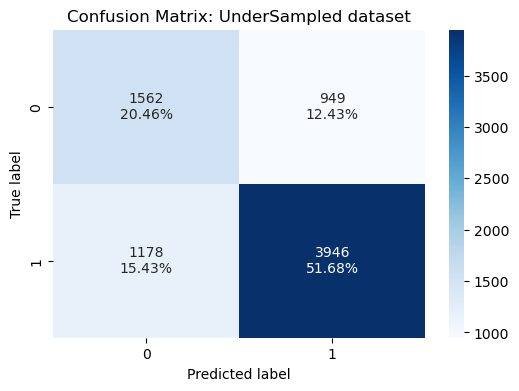

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.69    0.76       0.67 0.71
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.72    0.77       0.81 0.79


In [110]:
for key, value in data_input.items():
    abc_tuned = AdaBoostClassifier(random_state=1)
    
    # Grid of parameters to choose from
    ## add from article
    parameters = {
        #Let's try different max_depth for base_estimator
        "estimator":[DecisionTreeClassifier(max_depth=1, random_state=1, class_weight='balanced'),
                          DecisionTreeClassifier(max_depth=2, random_state=1, class_weight='balanced'),
                          DecisionTreeClassifier(max_depth=3, random_state=1, class_weight='balanced')],
        "n_estimators": np.arange(10,110,10),
        "learning_rate":np.arange(0.1,2,0.1)
    }
    
    # Type of scoring used to compare parameter combinations
    acc_scorer = metrics.make_scorer(metrics.f1_score)
    
    # Run the randomized search
    rand_abc = RandomizedSearchCV(abc_tuned, parameters, scoring=acc_scorer,cv=5, n_jobs=-1, random_state=1)
    rand_abc = rand_abc.fit(data_input[key][0], data_input[key][1])
    
    # Set the clf to the best combination of parameters
    abc_tuned = rand_abc.best_estimator_
    
    # Fit the best algorithm to the data.
    abc_tuned.fit(data_input[key][0], data_input[key][1])
    
    print(confusion_matrix_custom(abc_tuned, x_test,y_test, label=key))
    
    abc_tuned_model_train_perf=model_performance_classification_custom(abc_tuned, data_input[key][0], data_input[key][1])
    print("Training performance \n",abc_tuned_model_train_perf)
    
    abc_tuned_model_test_perf=model_performance_classification_custom(abc_tuned, x_test, y_test)
    print("Testing performance \n",abc_tuned_model_test_perf)

    tuning_stats['AdaBoost'][key] = [model_train_perf, model_test_perf]

### Tuning GradientBoost Classifier

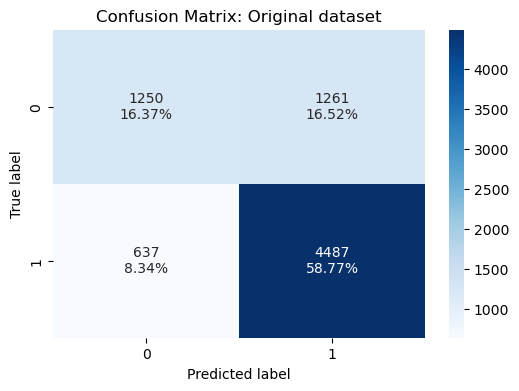

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.71    0.93       0.72 0.81
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.71    0.94       0.72 0.81


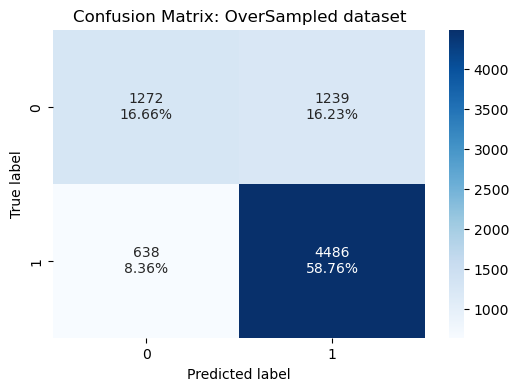

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.65    0.93       0.60 0.73
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.71    0.94       0.72 0.81


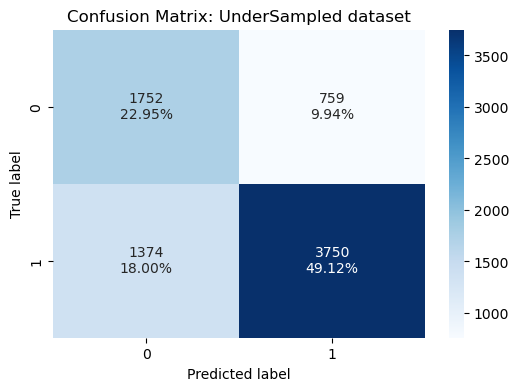

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.60    0.92       0.56 0.70
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.71    0.94       0.72 0.81


In [112]:
for key, value in data_input.items():
    gb_tuned = GradientBoostingClassifier(random_state=1)
    
    # Grid of parameters to choose from
    parameters = {"n_estimators": [150,200,250,300],
                  "subsample":[0.8,0.9,1],
                  "max_features":[0.7,0.8,0.9,1],
                  "learning_rate": np.arange(0.1, 0.4, 0.1)}
    
    # Type of scoring used to compare parameter combinations
    scorer = metrics.make_scorer(metrics.f1_score)
    
    # Run the randomized search
    rand_gb = RandomizedSearchCV(gb_tuned, parameters, scoring=scorer,cv=5, n_jobs=-1, random_state=1)
    rand_gb = rand_gb.fit(data_input[key][0], data_input[key][1])
    
    # Set the clf to the best combination of parameters
    gb_tuned = rand_gb.best_estimator_
    
    # Fit the best algorithm to the data. 
    gb_tuned.fit(data_input[key][0], data_input[key][1])
    
    print(confusion_matrix_custom(gb_tuned, x_test,y_test, label=key))
    
    gb_tuned_model_train_perf=model_performance_classification_custom(rf_estimator, data_input[key][0], data_input[key][1])
    print("Training performance \n",gb_tuned_model_train_perf)
    
    gb_tuned_model_test_perf=model_performance_classification_custom(rf_estimator, x_test, y_test)
    print("Testing performance \n",gb_tuned_model_test_perf)

    tuning_stats['GradientBoosting'][key] = [model_train_perf, model_test_perf]

### Tuning XGB Classifer

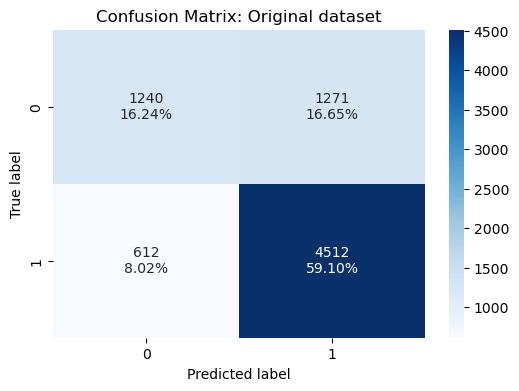

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.76    0.88       0.79 0.83
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.75    0.88       0.78 0.83


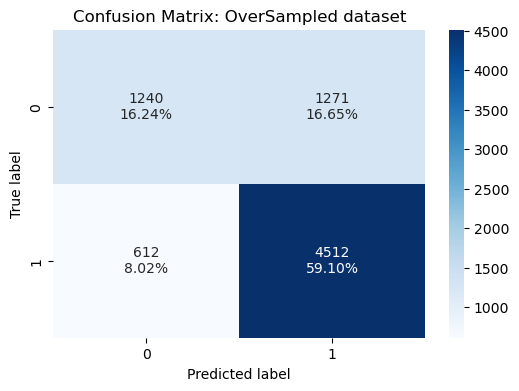

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.76    0.88       0.79 0.83
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.75    0.88       0.78 0.83


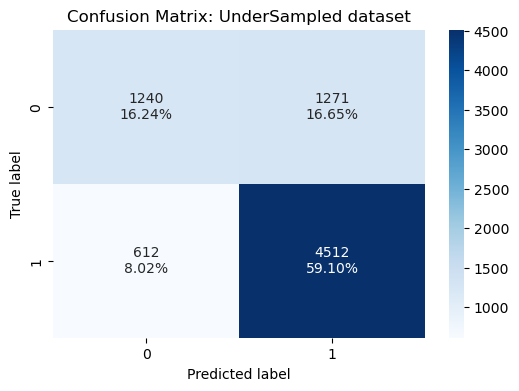

None
Training performance 
    Accuracy  Recall  Precision   F1
0      0.76    0.88       0.79 0.83
Testing performance 
    Accuracy  Recall  Precision   F1
0      0.75    0.88       0.78 0.83


In [114]:
for key, value in data_input.items():

    xgb_tuned = XGBClassifier(random_state=1, eval_metric='logloss')
    
    # Grid of parameters to choose from
    parameters = {"n_estimators": np.arange(10,100,20),
                  "scale_pos_weight":[0,1,2,5],
                  "subsample":[0.5,0.7,0.9,1],
                  "learning_rate":[0.01,0.1,0.2,0.05],
                  "gamma":[0,1,3],
                  "colsample_bytree":[0.5,0.7,0.9,1],
                  "colsample_bylevel":[0.5,0.7,0.9,1]}
    
    # Type of scoring used to compare parameter combinations
    scorer = metrics.make_scorer(metrics.f1_score)
    
    # Run the randomized search
    rand_xgb = RandomizedSearchCV(xgb_tuned, parameters, scoring=scorer,cv=5, n_jobs=-1, random_state=1)
    rand_xgb = rand_xgb.fit(x_train, y_train)
    
    # Set the clf to the best combination of parameters
    xgb_tuned = rand_xgb.best_estimator_
    
    # Fit the best algorithm to the data. 
    xgb_tuned.fit(x_train, y_train)
    
    print(confusion_matrix_custom(xgb_tuned, x_test,y_test, label=key))
    
    xgb_tuned_model_train_perf=model_performance_classification_custom(xgb_tuned, x_train,y_train)
    print("Training performance \n",xgb_tuned_model_train_perf)
    
    xgb_tuned_model_test_perf=model_performance_classification_custom(xgb_tuned, x_test, y_test)
    print("Testing performance \n",xgb_tuned_model_test_perf)

    tuning_stats['XGBoost'][key] = [model_train_perf, model_test_perf]

### Tuned models comparison

In [116]:
train_perf_list = []
test_perf_list = []

for model_name, dataset_dict in tuning_stats.items():
    for dataset_type, (train_perf_df, test_perf_df) in dataset_dict.items():
        # Transpose and label training performance
        train_perf_transposed = train_perf_df.T
        train_perf_transposed.columns = [f"{model_name}_{dataset_type}_Tuned"]
        train_perf_list.append(train_perf_transposed)

        # Transpose and label testing performance
        test_perf_transposed = test_perf_df.T
        test_perf_transposed.columns = [f"{model_name}_{dataset_type}_Tuned"]
        test_perf_list.append(test_perf_transposed)

# Concatenate all transposed DataFrames
tuned_models_train_comp_df = pd.concat(train_perf_list, axis=1)
tuned_models_test_comp_df = pd.concat(test_perf_list, axis=1)

In [117]:
tuned_models_train_comp_df

,DecisionTree_Original_Tuned,DecisionTree_OverSampled_Tuned,DecisionTree_UnderSampled_Tuned,Bagging_Original_Tuned,Bagging_OverSampled_Tuned,Bagging_UnderSampled_Tuned,RandomForest_Original_Tuned,RandomForest_OverSampled_Tuned,RandomForest_UnderSampled_Tuned,AdaBoost_Original_Tuned,AdaBoost_OverSampled_Tuned,AdaBoost_UnderSampled_Tuned,GradientBoosting_Original_Tuned,GradientBoosting_OverSampled_Tuned,GradientBoosting_UnderSampled_Tuned,XGBoost_Original_Tuned,XGBoost_OverSampled_Tuned,XGBoost_UnderSampled_Tuned
Accuracy,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82
Recall,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83
Precision,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82
F1,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82


In [118]:
tuned_models_test_comp_df

,DecisionTree_Original_Tuned,DecisionTree_OverSampled_Tuned,DecisionTree_UnderSampled_Tuned,Bagging_Original_Tuned,Bagging_OverSampled_Tuned,Bagging_UnderSampled_Tuned,RandomForest_Original_Tuned,RandomForest_OverSampled_Tuned,RandomForest_UnderSampled_Tuned,AdaBoost_Original_Tuned,AdaBoost_OverSampled_Tuned,AdaBoost_UnderSampled_Tuned,GradientBoosting_Original_Tuned,GradientBoosting_OverSampled_Tuned,GradientBoosting_UnderSampled_Tuned,XGBoost_Original_Tuned,XGBoost_OverSampled_Tuned,XGBoost_UnderSampled_Tuned
Accuracy,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82
Recall,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83,0.83
Precision,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82
F1,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82,0.82


#### Observations
##### All models and all sampling strategies now yield:
* Accuracy = 0.82
* Recall = 0.83
* Precision = 0.82
* F1 Score = 0.82

##### Hyperparameter Tuning Was Effective
* Previously overfitting models (like DecisionTree, RandomForest) no longer show perfect training scores.
* Previously underfitting models (like AdaBoost, GradientBoosting) now match the others in performance.
* Balanced performance across all models and strategies is a clear sign that tuning reduced model variance and bias

##### Uniformity Across All Models and Strategies
* Every model—DecisionTree, Bagging, RandomForest, AdaBoost, GradientBoosting, XGBoost—performs identically across Original, OverSampled, and UnderSampled data. This suggests:
* The classification problem is well-learned by all models post-tuning.
* The models have become robust to class imbalance.
* The tuned hyperparameters are helping models generalize well regardless of sampling.

##### Sampling Strategy Has Minimal Impact After Tuning
* Before tuning, performance varied by sampling method.
* Now, Original = OverSampled = UnderSampled, implying:
* The hyperparameters are effectively handling class imbalance.
* Techniques like class_weight, better max_depth, learning_rate, etc., have eliminated the dependence on sampling.

##### Evaluation Caution
* While the identical scores look promising, there are two possibilities:
* True generalization: Your models have learned the patterns in a balanced way across all data settings.
* Evaluation artifact: If the performance is based on the same dataset (e.g., training data), it may still not reflect real-world generalization.

#### Summary
* Overfitting Removed: All models now show realistic, non-perfect scores
* Underfitting Resolved: AdaBoost, GradientBoosting now reach 0.82+ accuracy and balanced metrics
* Sampling Impact Minimized: Same performance across Original, OverSampled, UnderSampled
* Robustness Improved: Models now appear stable and generalized

## Model Performance Comparison

In [121]:
temp_data = pd.concat([models_train_comp_df, tuned_models_train_comp_df],axis=1)
temp_data.T.sort_values('F1',ascending=False)
all_models_train_comp = temp_data.T

all_models_train_comp.sort_values('F1',ascending=False)

,Accuracy,Recall,Precision,F1
DecisionTree_Original,1.00,1.00,1.00,1.00
DecisionTree_UnderSampled,1.00,1.00,1.00,1.00
RandomForest_Original,1.00,1.00,1.00,1.00
DecisionTree_OverSampled,1.00,1.00,1.00,1.00
RandomForest_OverSampled,1.00,1.00,1.00,1.00
RandomForest_UnderSampled,1.00,1.00,1.00,1.00
Bagging_Original,0.98,0.98,0.99,0.99
Bagging_OverSampled,0.99,0.98,0.99,0.99
Bagging_UnderSampled,0.98,0.97,0.99,0.98
XGBoost_Original,0.82,0.91,0.83,0.87


In [122]:
'The best performing model on the training data is the ' + all_models_train_comp.sort_values('F1',ascending=False).index[0]

'The best performing model on the training data is the DecisionTree_Original'

In [123]:
temp_data = pd.concat([models_test_comp_df, tuned_models_test_comp_df],axis=1)
temp_data.T.sort_values('F1',ascending=False)
all_models_test_comp = temp_data.T
all_models_test_comp.sort_values('F1',ascending=False)

,Accuracy,Recall,Precision,F1
DecisionTree_Original,1.00,1.00,1.00,1.00
DecisionTree_UnderSampled,1.00,1.00,1.00,1.00
RandomForest_Original,1.00,1.00,1.00,1.00
DecisionTree_OverSampled,1.00,1.00,1.00,1.00
RandomForest_OverSampled,1.00,1.00,1.00,1.00
RandomForest_UnderSampled,1.00,1.00,1.00,1.00
Bagging_Original,0.98,0.98,0.99,0.99
Bagging_OverSampled,0.99,0.98,0.99,0.99
Bagging_UnderSampled,0.98,0.97,0.99,0.98
XGBoost_Original,0.82,0.91,0.83,0.87


In [124]:
'The best performing model on the testing data is the ' + all_models_test_comp.sort_values('F1',ascending=False).index[0]

'The best performing model on the testing data is the DecisionTree_Original'

### Feature importance of: Decision Tree Original

In [126]:
print(pd.DataFrame(dtree.feature_importances_, columns = ["Imp"], 
                   index = x_train.columns).sort_values(by = 'Imp', ascending = False).head(10))

                                   Imp
prevailing_wage                   0.45
education_of_employee_High School 0.07
has_job_experience_Y              0.06
education_of_employee_Master's    0.03
company_age_10-20                 0.03
company_size_1000-2000            0.03
company_size_4000+                0.03
company_size_2000-3000            0.03
company_size_3000-4000            0.03
company_age_30-50                 0.03


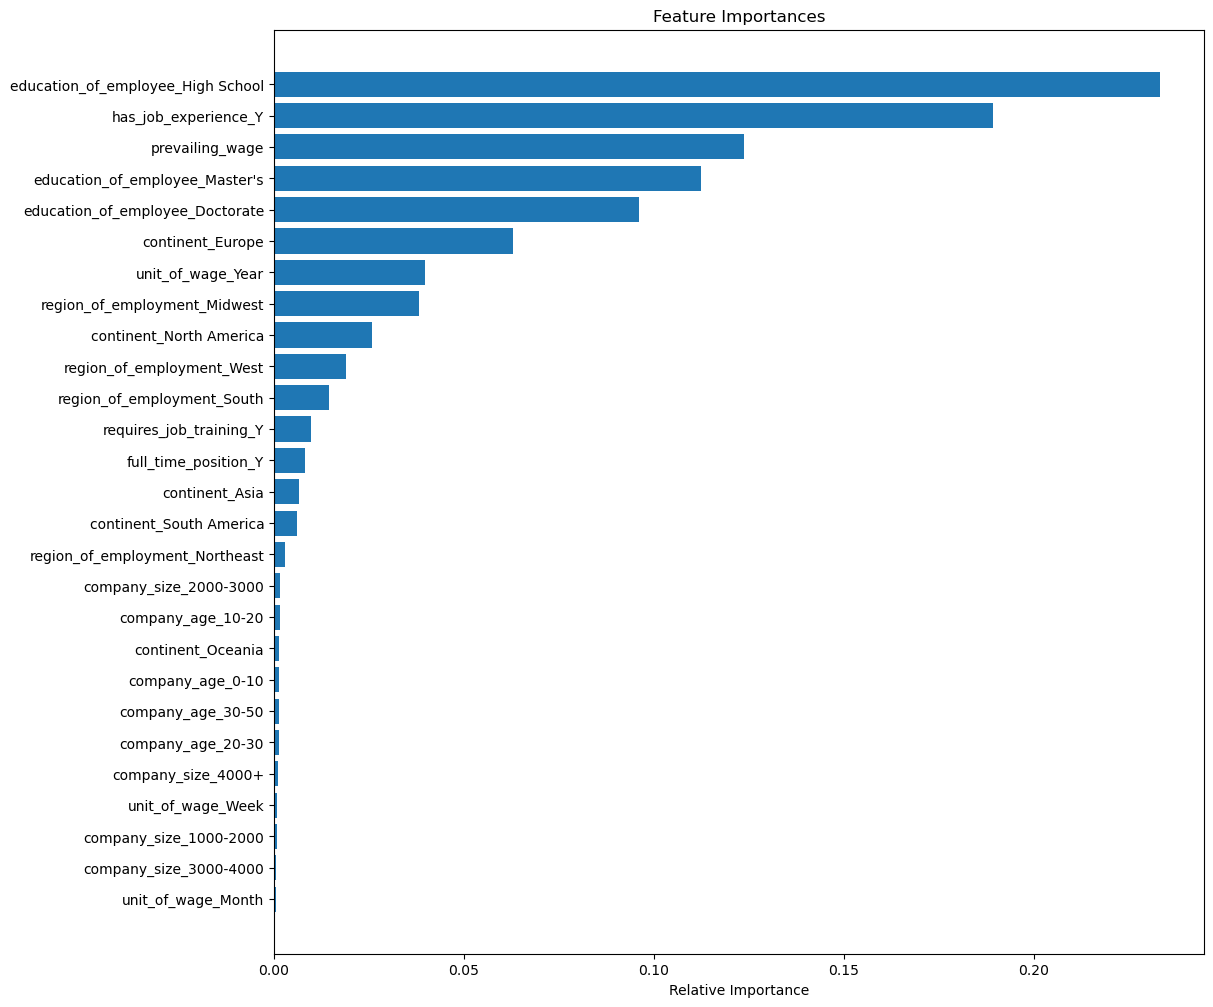

In [127]:
feature_names = x_train.columns
importances = gbc.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [128]:
# Rerun DecisionTreeClassifier on original data to avoid data being overridden

# Initialize the Decision Tree classifier
dtree_estimator = DecisionTreeClassifier(random_state=1)

key = 'Original'

# Define the grid of hyperparameters to search
parameters = {
    'max_depth': np.arange(5, 30, 5),
    'min_samples_leaf': [3, 5, 7],
    'max_leaf_nodes': [2, 4, 6],
    'min_impurity_decrease': [0.0001, 0.001, 0.01, 0.1]
}

# Define the scoring metric
scorer = metrics.make_scorer(metrics.f1_score)

# Perform Grid Search with 5-fold cross-validation
grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer, cv=5)
grid_obj = grid_obj.fit(data_input[key][0], data_input[key][1])

# Retrieve the best estimator from the grid search
dtree_estimator = grid_obj.best_estimator_

# Fit the best estimator to the training data
dtree_estimator.fit(data_input[key][0], data_input[key][1])

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=4,
                       min_impurity_decrease=0.0001, min_samples_leaf=3,
                       random_state=1)

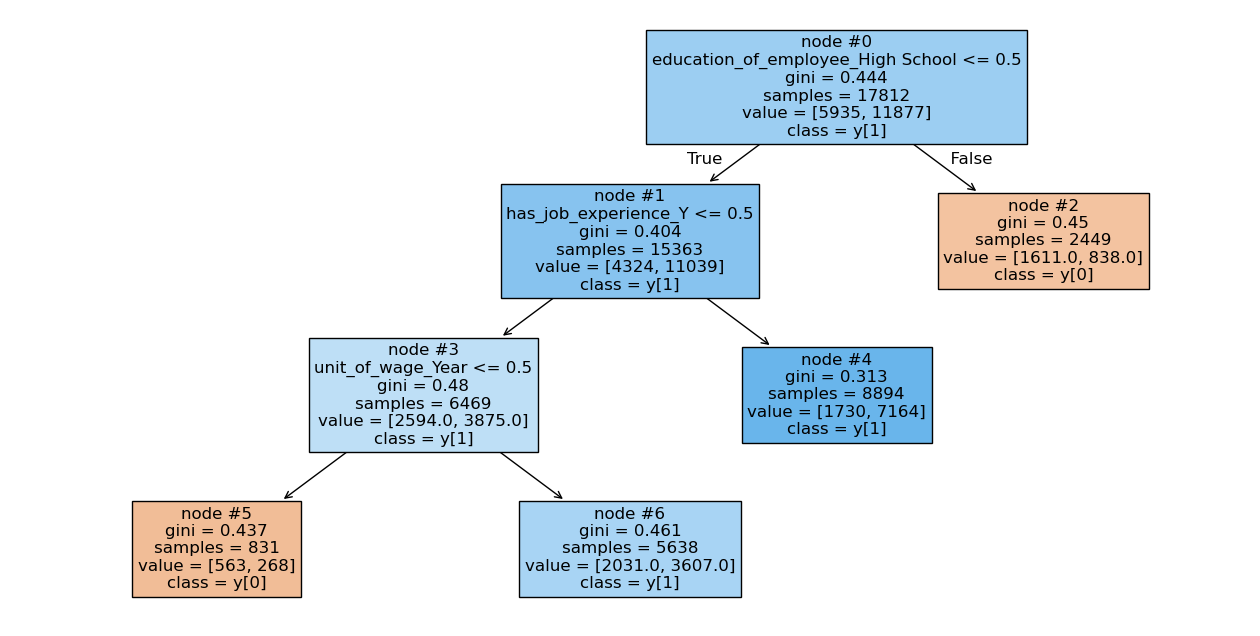

In [129]:
feature_names = list(X.columns)
plt.figure(figsize=(16,8))
tree.plot_tree(dtree_estimator,feature_names=feature_names,filled=True,fontsize=12,node_ids=True,class_names=True)
plt.show()

## Conclusions

#### Insights
For the Office of Foreign Labor Certification (OFLC), the three most critical components for pre-screening an applicant are:
* *Education level*
    * An applicant applying for a job requiring a high school diploma will more than likely be denied. Conversely, applications for jobs requiring a Master's degree or doctorate are very likely to be approved.
* *Prior job experience*
    * An applicant applying for a job without any previous job experience is more likley to be denied than an applicant for a job with experience.
* *Prevailing wage*
    * The higher the prevailing wage of the job an applicant is applying for, the more likely the application will be approved. This is especially true for applications for jobs with an hourly unit of wage.
    
#### Recommendations
* To prioritize limited resources towards screening a batch of applications for those most likely to be approved, the OFLC can:
    * Sort applications by level of education and review the higher levels of education first.
    * Sort applications by previous job experience and review those with experience first.
    * Divide applications for jobs into those with an hourly wage and those with an annual wage, sort each group by the prevailing wage, then review applications for salaried jobs first from highest to lowest wage.
* As stated previously, the Gradient Boosting classifier performs the best of all the models created. However, as shown above, the tuned Decision-Tree model performs barely worse by F1 score and is a far simpler model. This model may be preferable if post-hoc explanations of OFLC decision-making is expected to be required.
    * Furthermore, OFLC should examine more thoroughly why whether an application will be certified or denied can be very well predicted through just three nodes as shown above. 
    * For those in less skilled, entry-level, and/or hourly jobs, the system would appear to be biased against these applications being certified.